# EDA project : credit Fraud Detection

## 1. Load and Overview

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [14]:
df = pd.read_csv('/home/remoo/Desktop/Credit_Card_Fraud_Detection/credit_detection/data/train.csv')

In [15]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


In [16]:
df.shape

(170884, 31)

In [17]:
df.nunique()

Time       99277
V1        166862
V2        166862
V3        166862
V4        166862
V5        166862
V6        166862
V7        166862
V8        166862
V9        166862
V10       166862
V11       166862
V12       166862
V13       166862
V14       166862
V15       166862
V16       166862
V17       166862
V18       166862
V19       166862
V20       166862
V21       166862
V22       166862
V23       166862
V24       166862
V25       166862
V26       166862
V27       166862
V28       166862
Amount     25361
Class          2
dtype: int64

array([  8.73,  59.95, 460.65, ..., 101.31, 680.77, 182.88],
      shape=(25361,))

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170884 entries, 0 to 170883
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    170884 non-null  float64
 1   V1      170884 non-null  float64
 2   V2      170884 non-null  float64
 3   V3      170884 non-null  float64
 4   V4      170884 non-null  float64
 5   V5      170884 non-null  float64
 6   V6      170884 non-null  float64
 7   V7      170884 non-null  float64
 8   V8      170884 non-null  float64
 9   V9      170884 non-null  float64
 10  V10     170884 non-null  float64
 11  V11     170884 non-null  float64
 12  V12     170884 non-null  float64
 13  V13     170884 non-null  float64
 14  V14     170884 non-null  float64
 15  V15     170884 non-null  float64
 16  V16     170884 non-null  float64
 17  V17     170884 non-null  float64
 18  V18     170884 non-null  float64
 19  V19     170884 non-null  float64
 20  V20     170884 non-null  float64
 21  V21     17

In [19]:
df.describe().round(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,...,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00,170884.00
mean,94966.11,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,...,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,88.51,0.00
std,47464.72,1.96,1.65,1.52,1.42,1.39,1.34,1.26,1.21,1.10,...,0.74,0.73,0.62,0.61,0.52,0.48,0.40,0.31,256.74,0.04
min,0.00,-46.86,-63.34,-48.33,-5.68,-113.74,-23.50,-43.56,-73.22,-13.43,...,-34.83,-10.93,-36.67,-2.84,-7.08,-2.60,-9.90,-15.43,0.00,0.00
25%,54348.00,-0.92,-0.60,-0.90,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.64,0.00
50%,84923.50,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.02,0.00
75%,139404.00,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.65,0.00
max,172792.00,2.45,22.06,4.23,16.88,34.10,73.30,120.59,18.28,10.39,...,27.20,10.50,22.53,4.58,6.07,3.52,31.61,16.13,25691.16,1.00


## 2 Data preperation 

In [20]:
df.duplicated().sum()

np.int64(448)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## feature extraction (time)

In [25]:
df['Time'] = df['Time'].apply(lambda x: x / 3600)  # convert seconds to hours

In [26]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,33.108611,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,19.930556,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,42.215833,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,15.474722,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,18.515000,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


## feature understanding 

In [28]:
def plot_numerical(df , feature):
    plt.figure(figsize=(15, 12))
    
    # histogram
    
    plt.subplot(1,3,1)
    sns.histplot(df[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # KDEplot 
    
    plt.subplot(1,3,2)
    sns.kdeplot(df[feature], color='teal', fill=True, alpha=0.5)
    plt.title(f'KDE Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    
    # Boxplot

    plt.subplot(1,3,3)
    sns.boxplot(y=df[feature], color='blue')
    plt.title(f'Box Plot of {feature}')
    plt.xlabel(feature)
    plt.show()

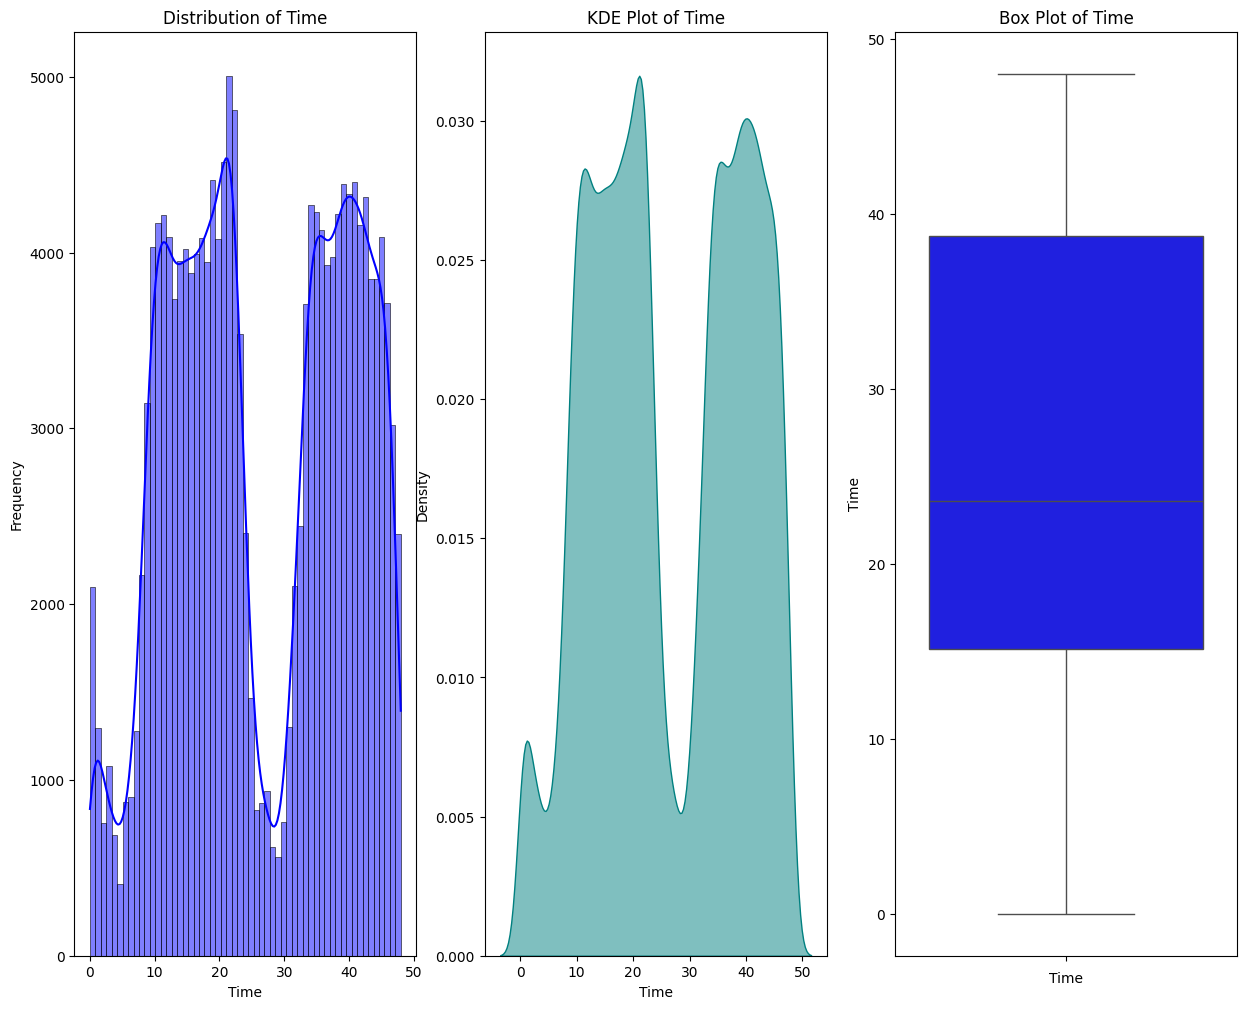

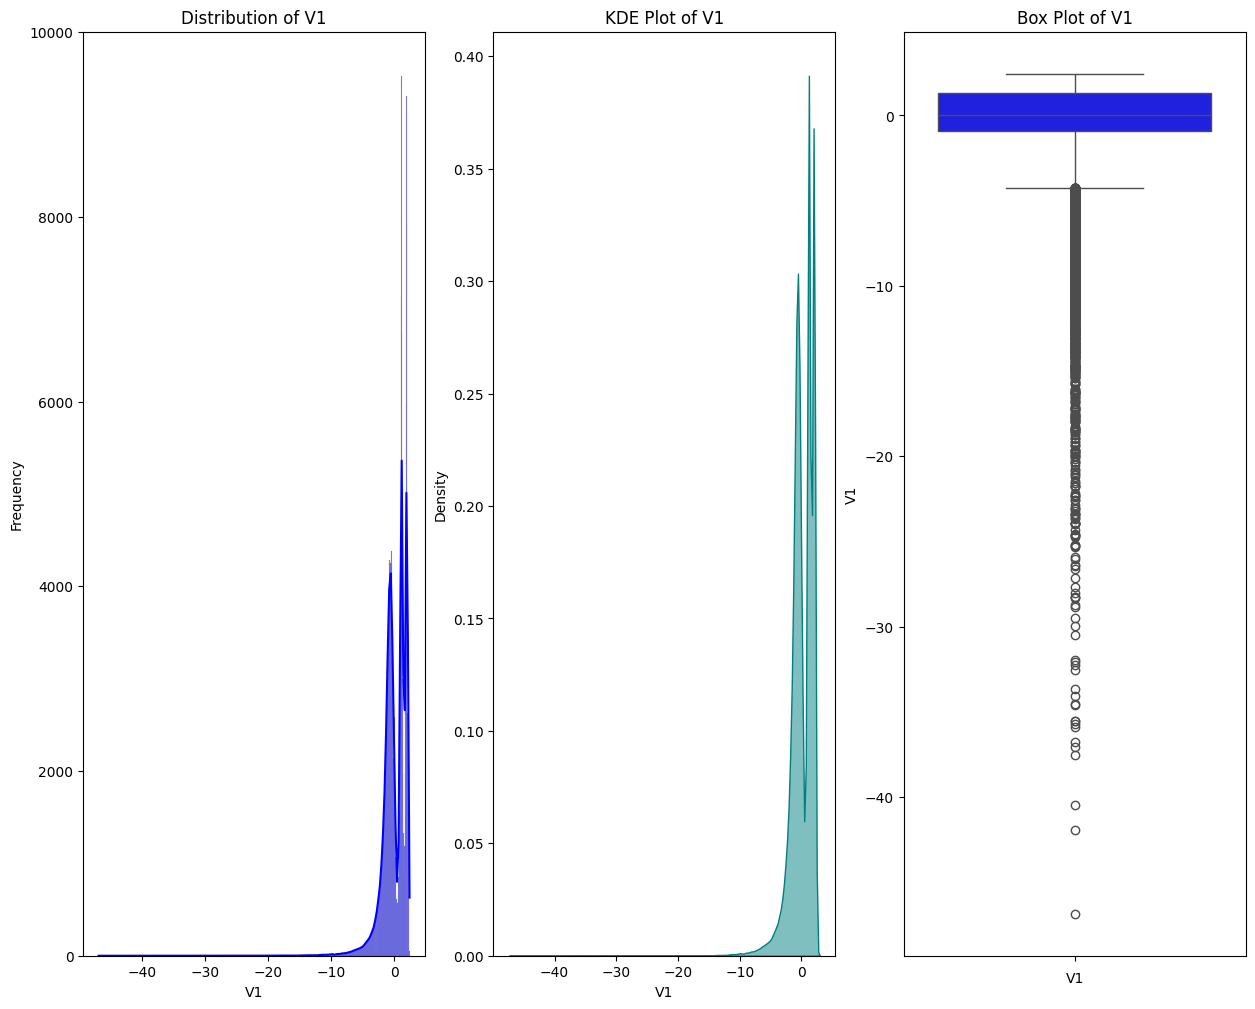

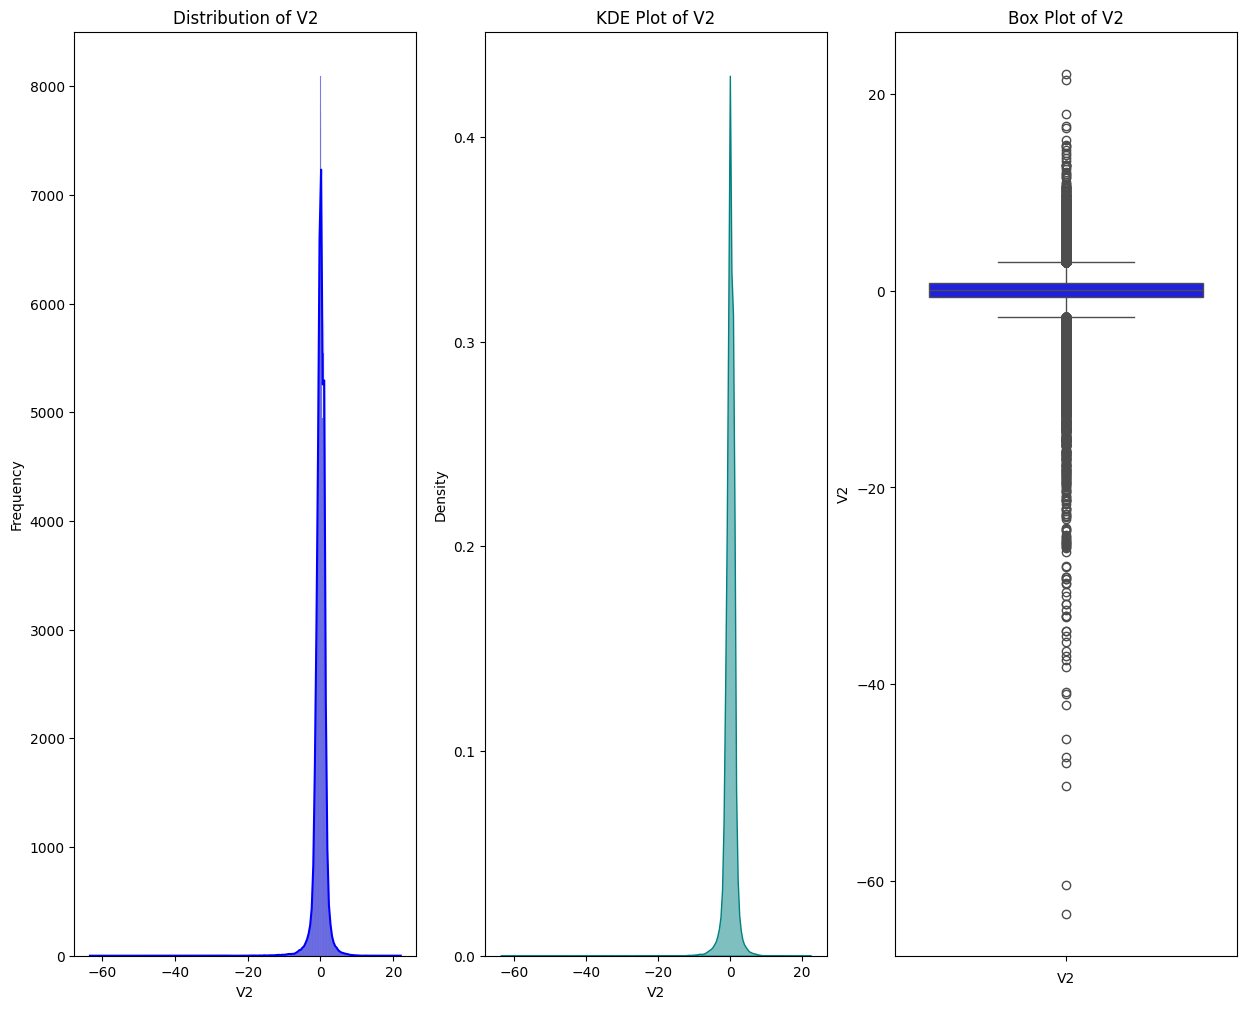

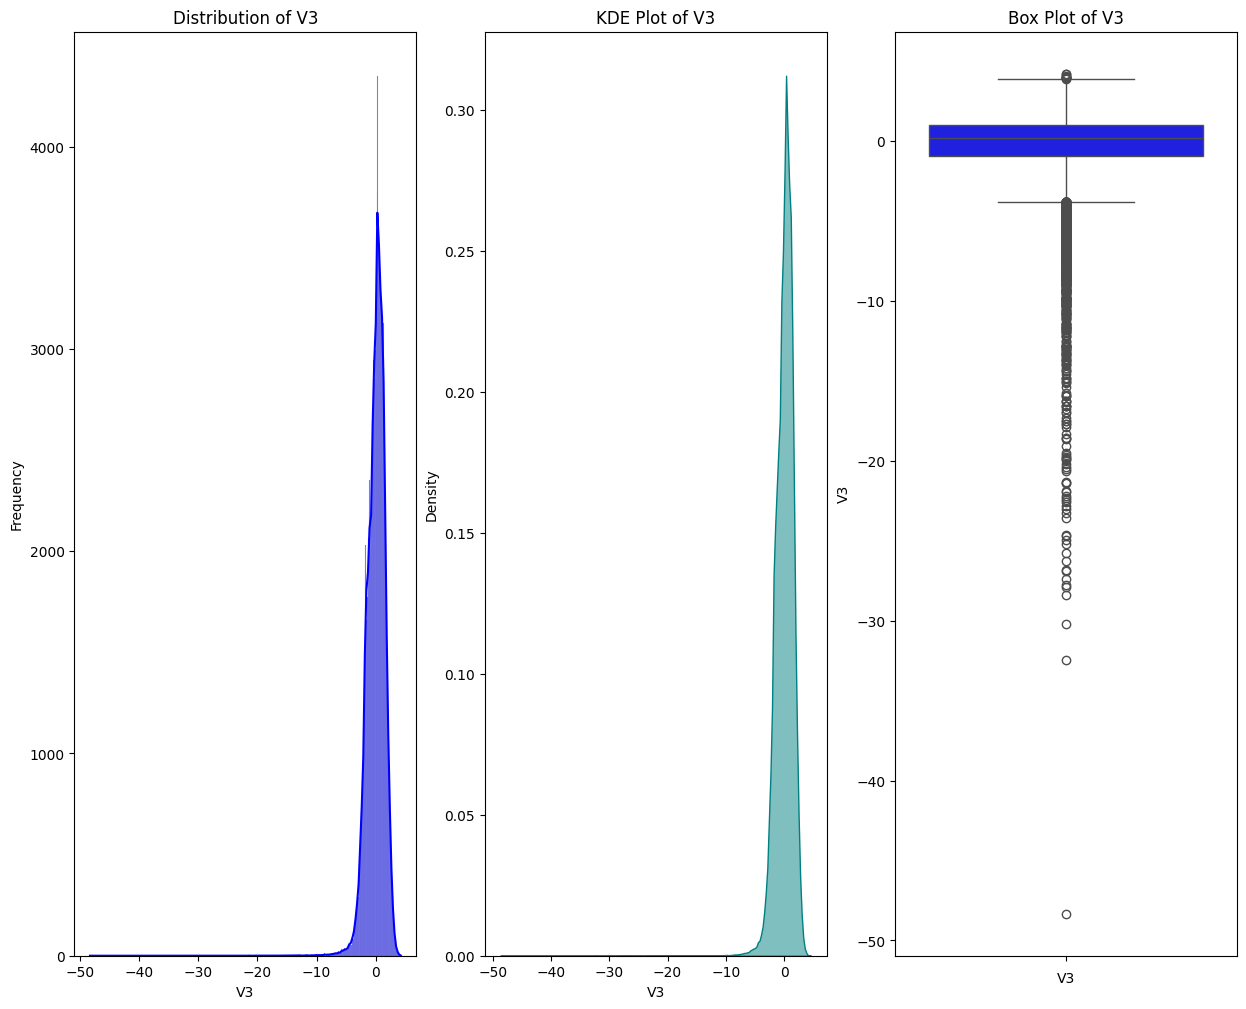

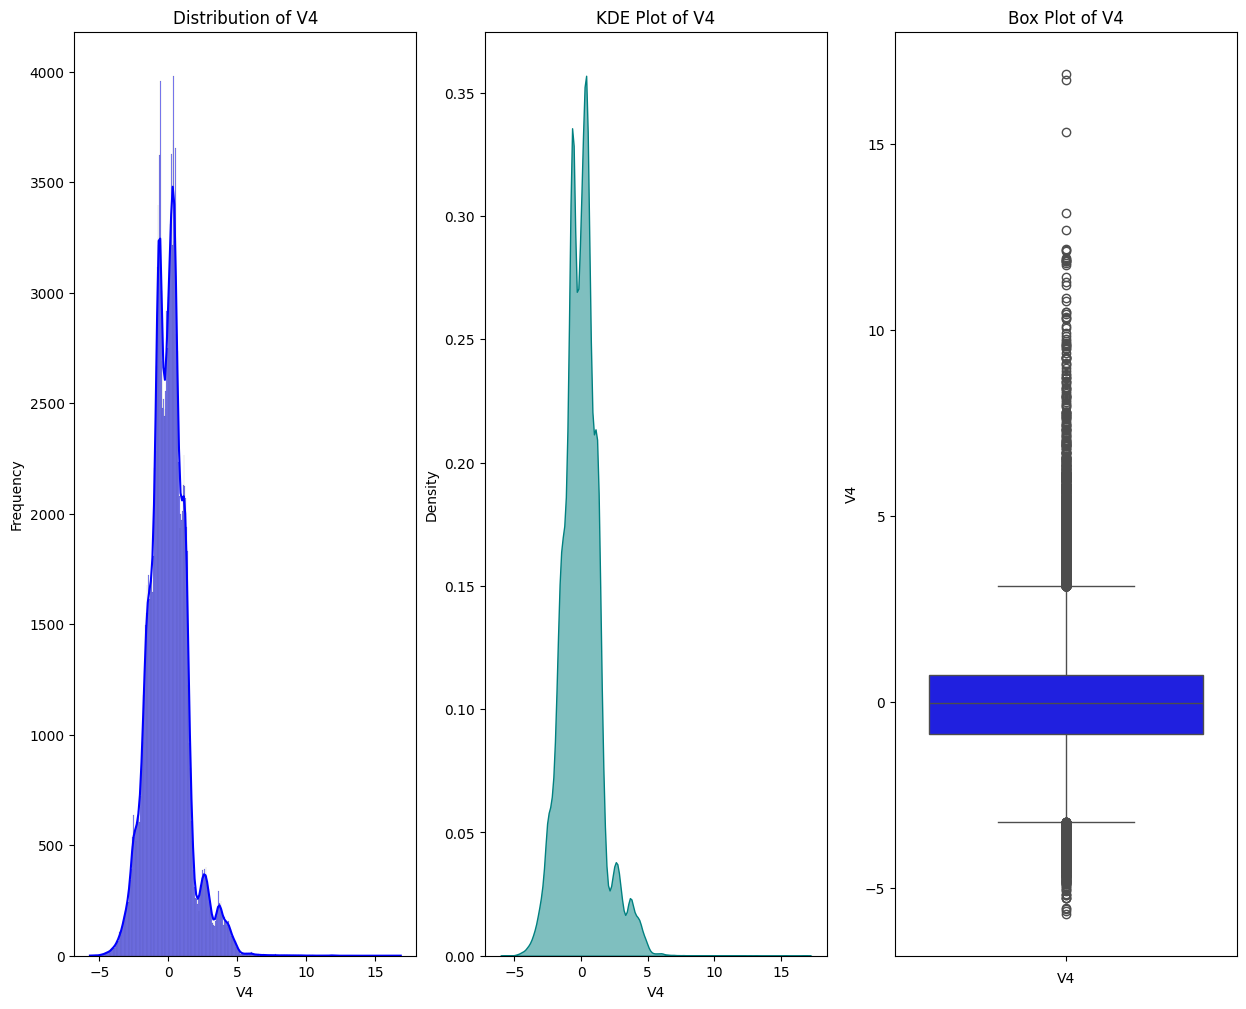

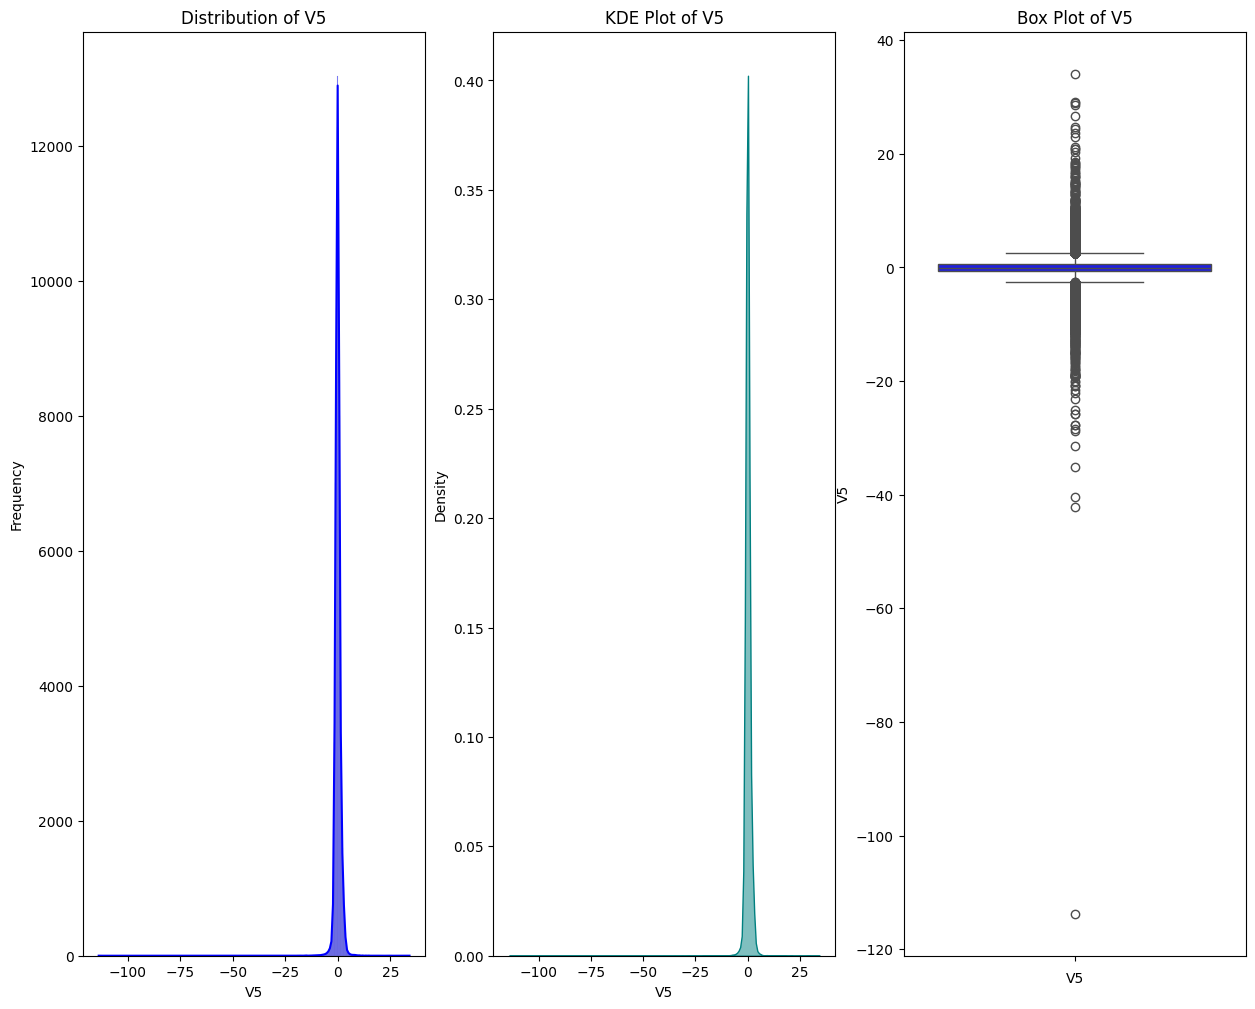

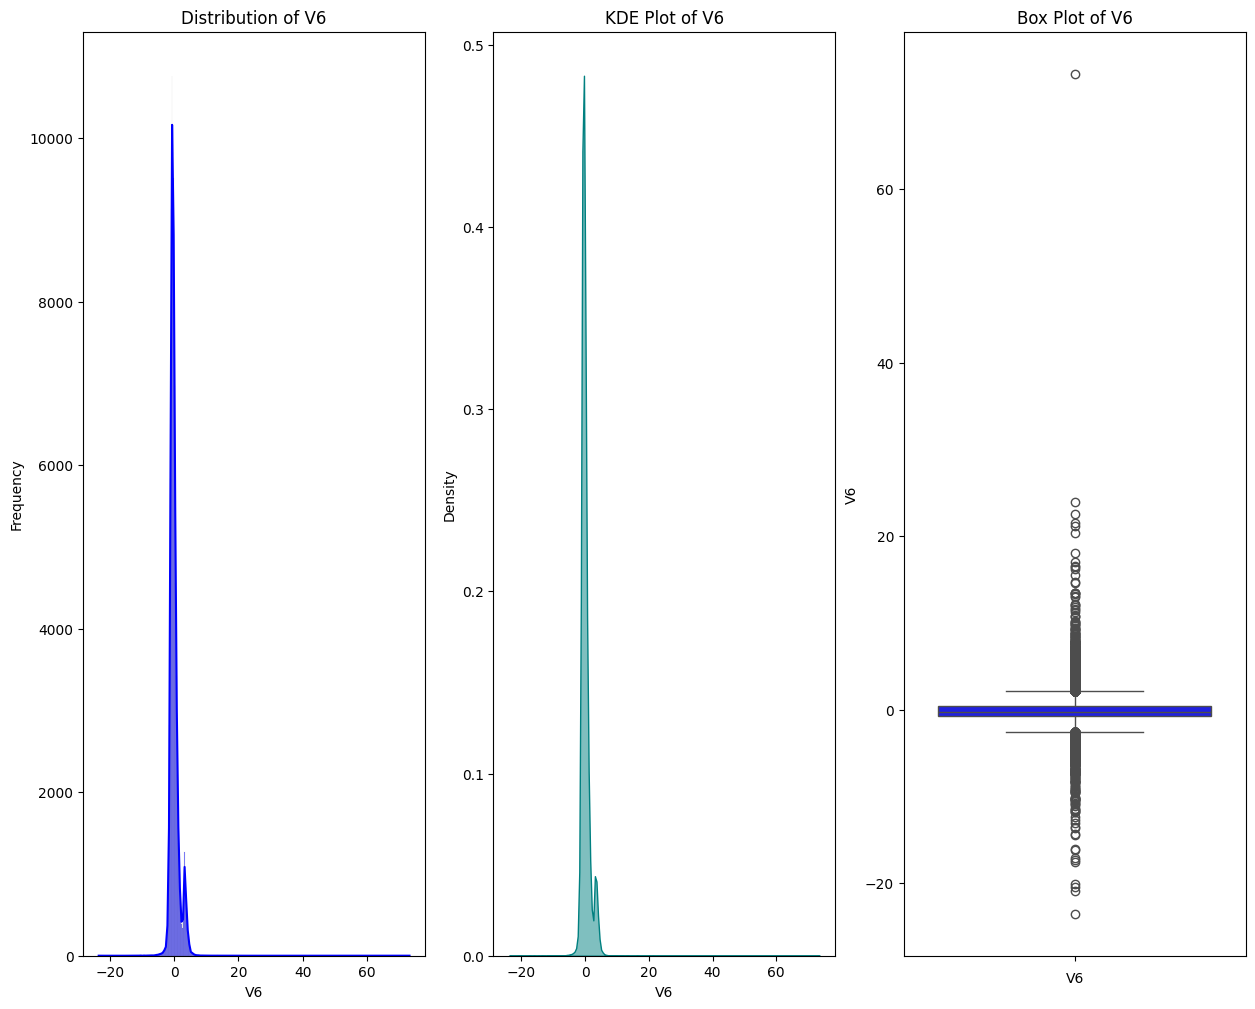

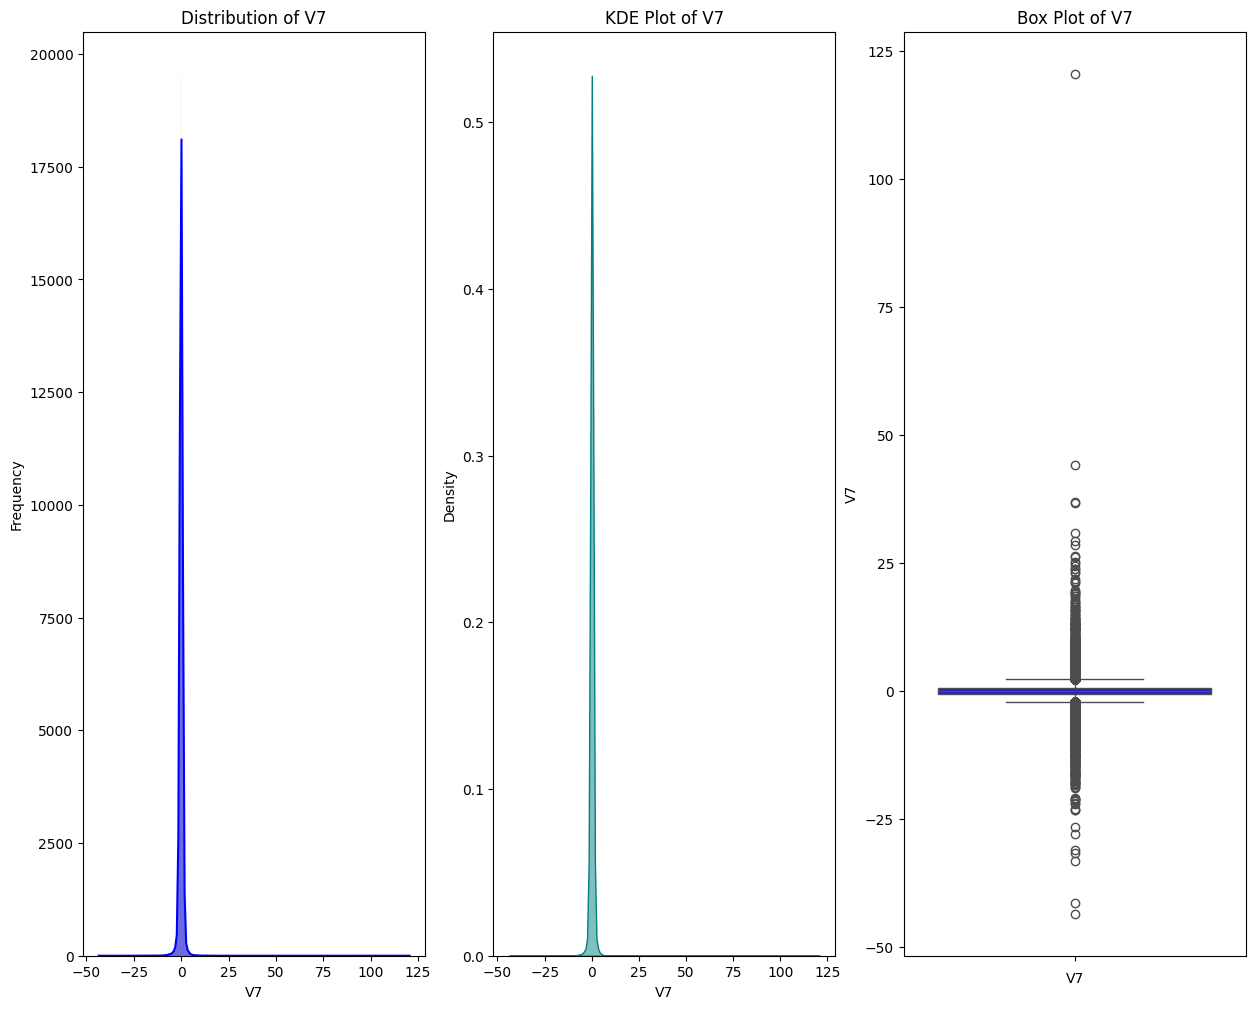

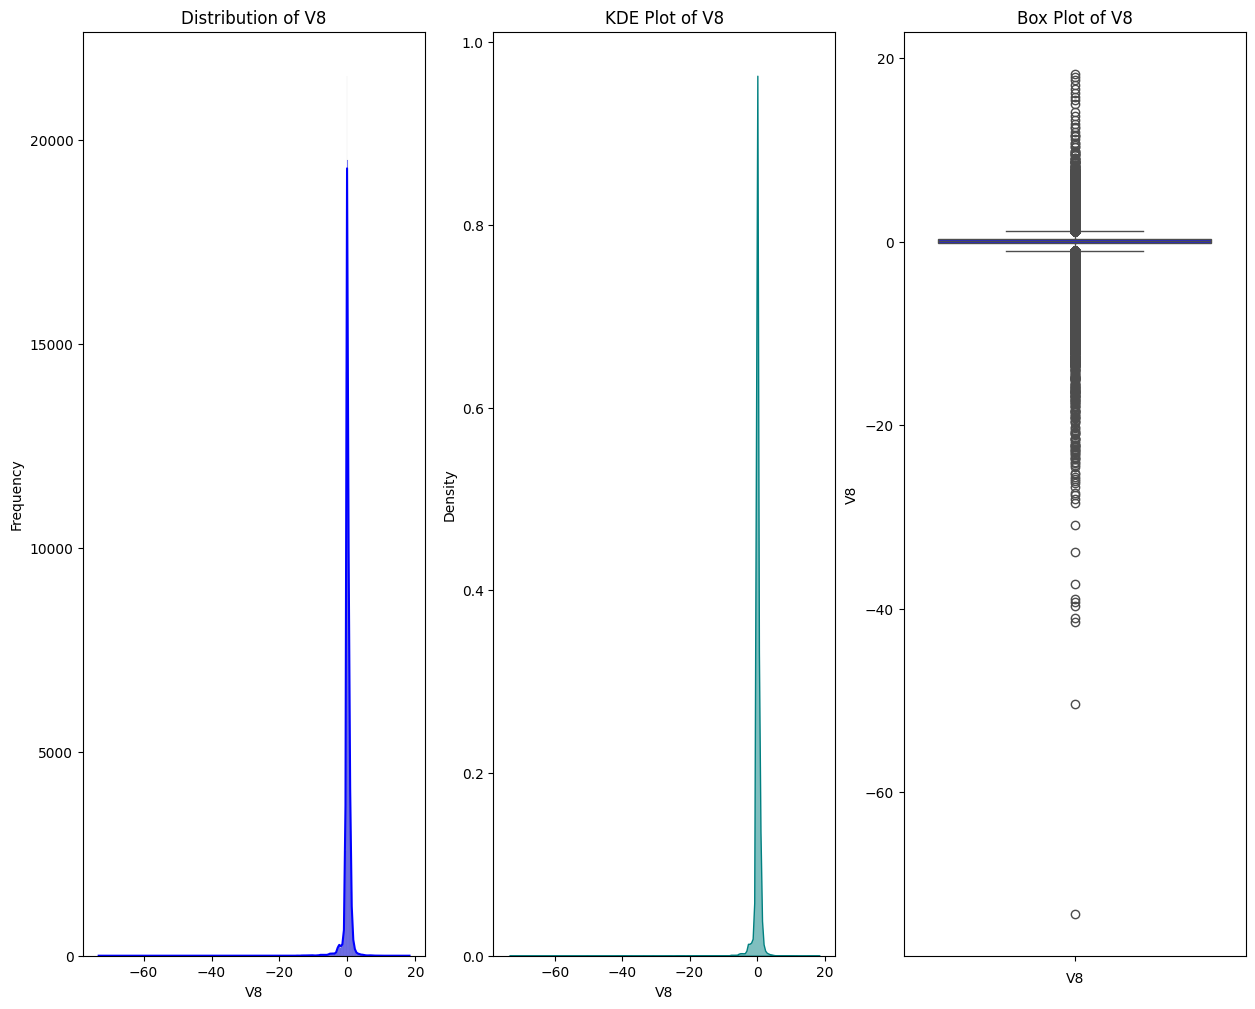

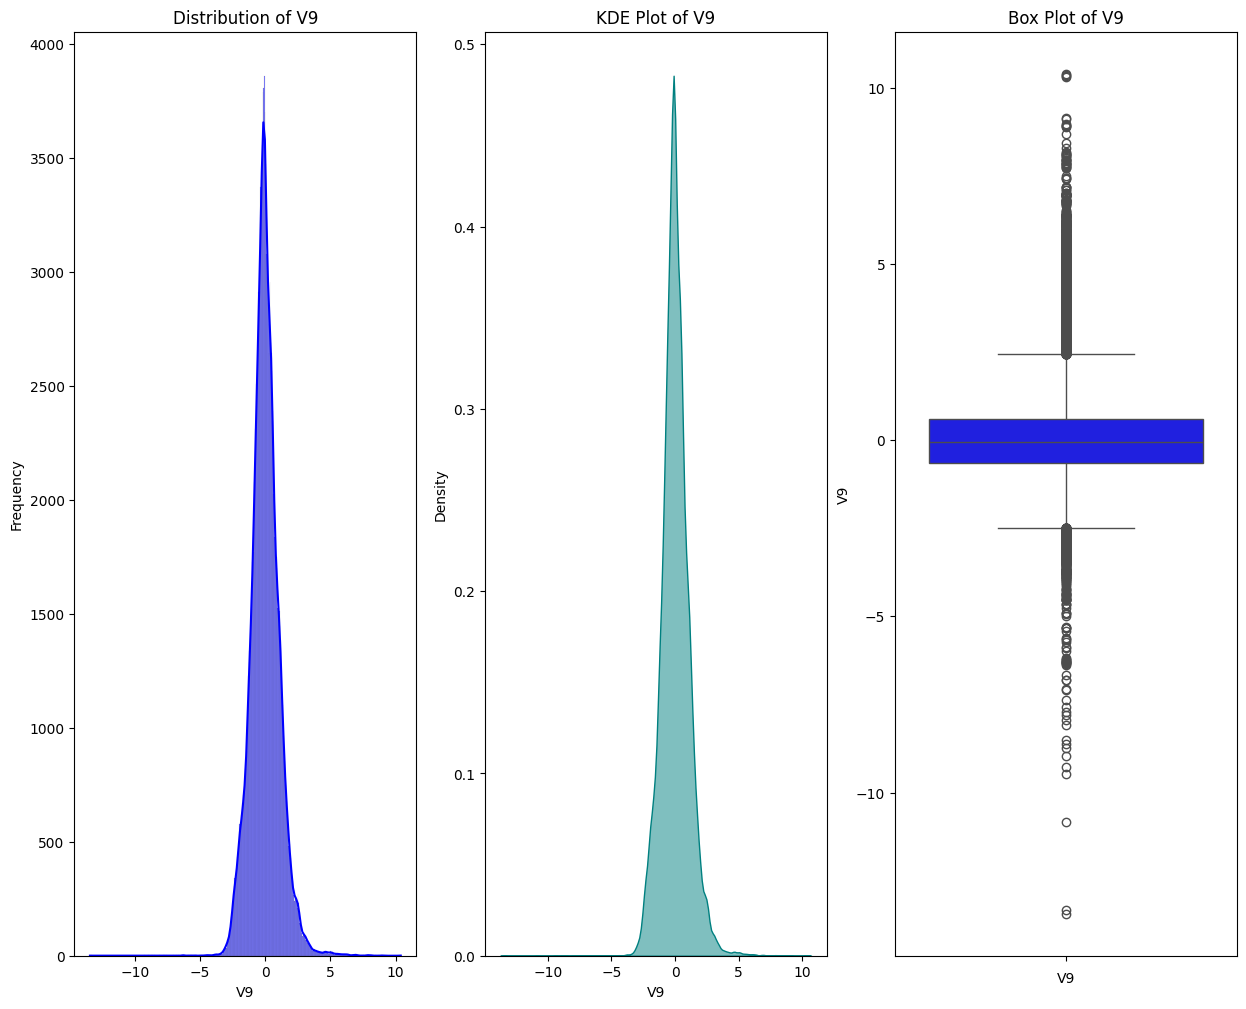

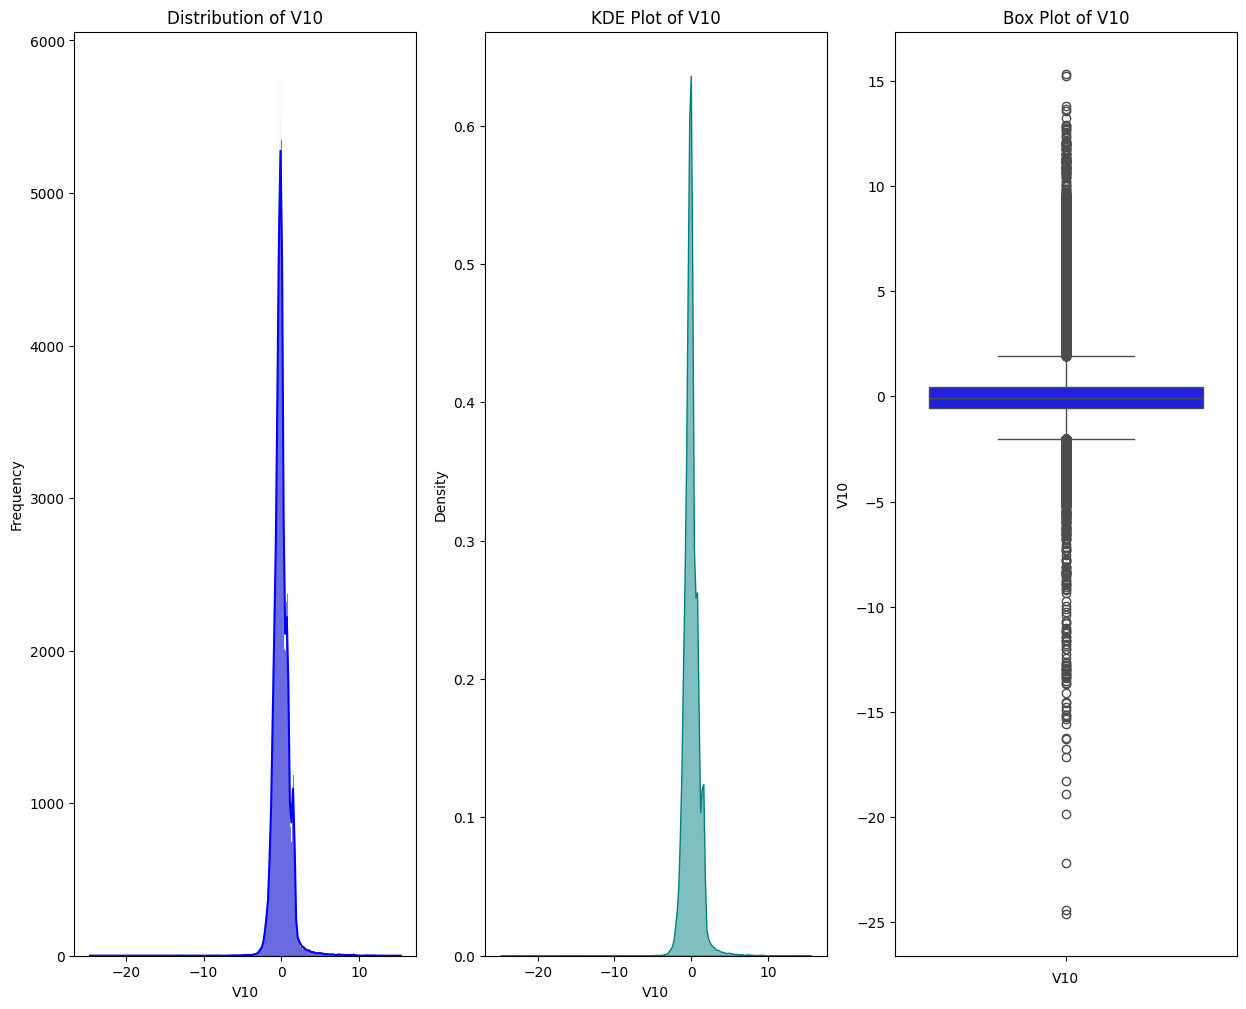

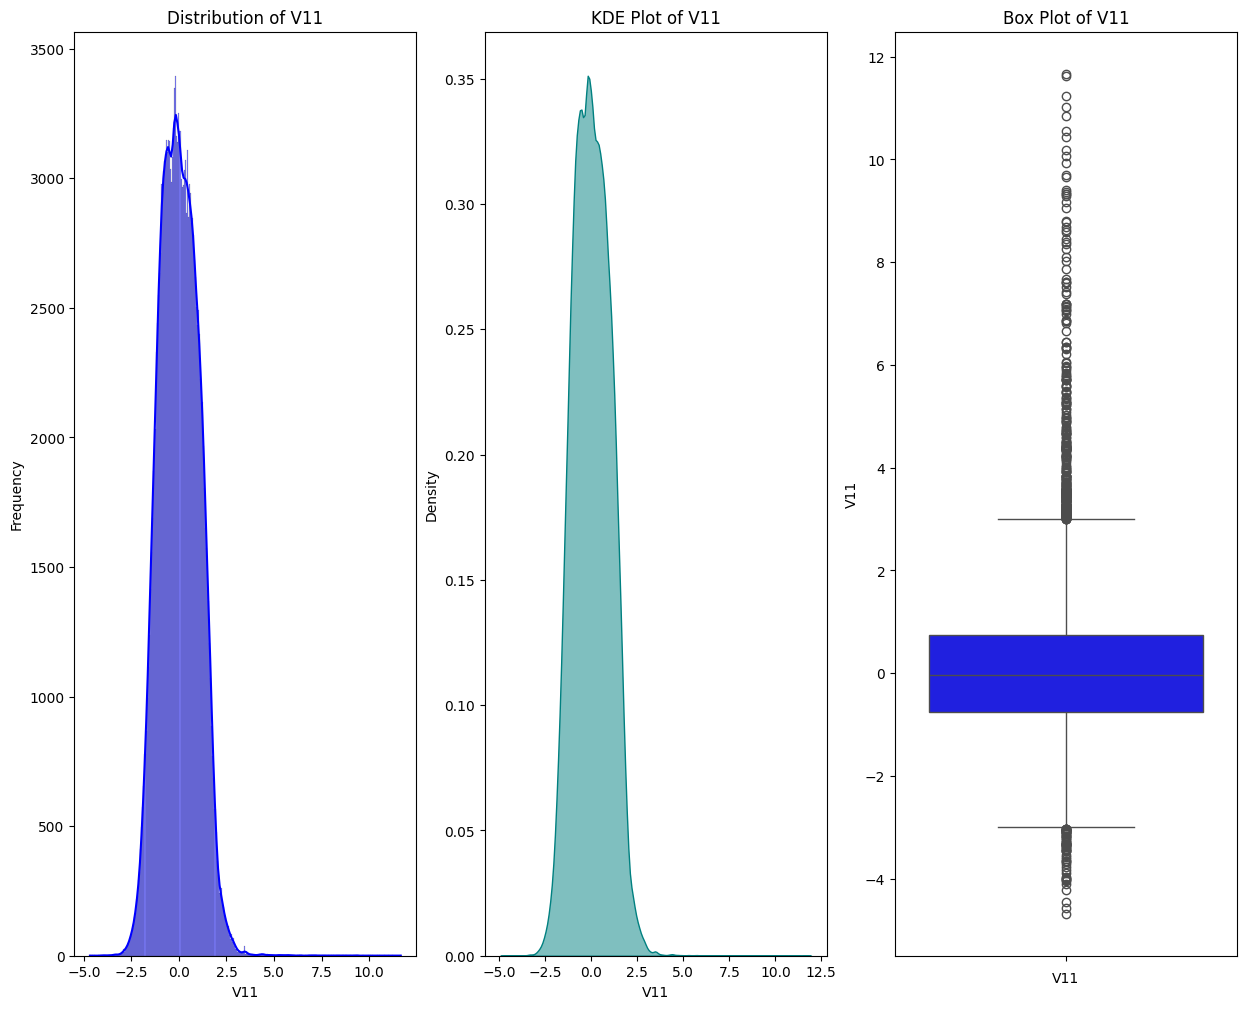

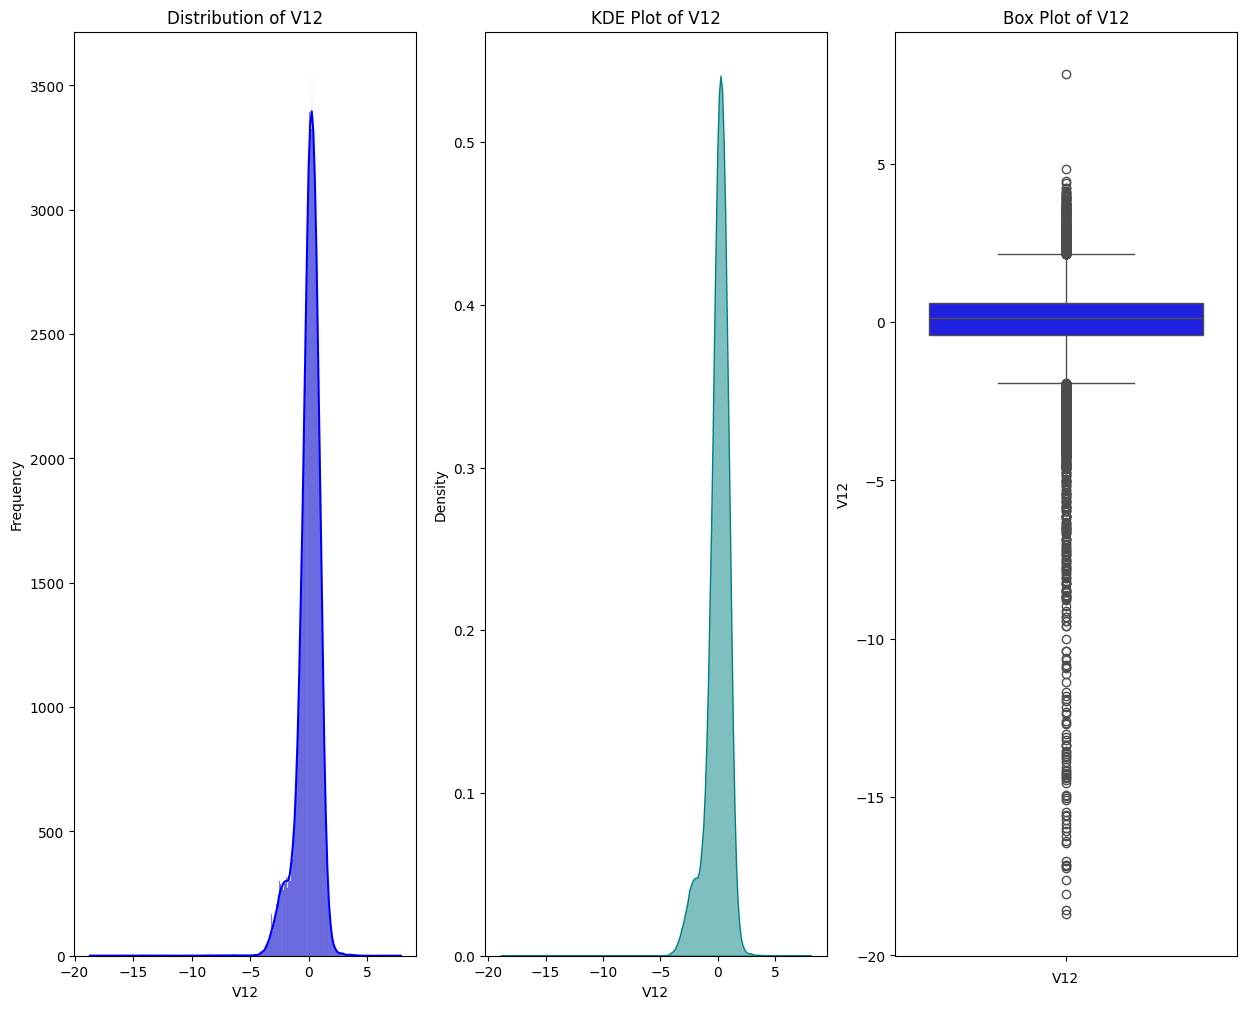

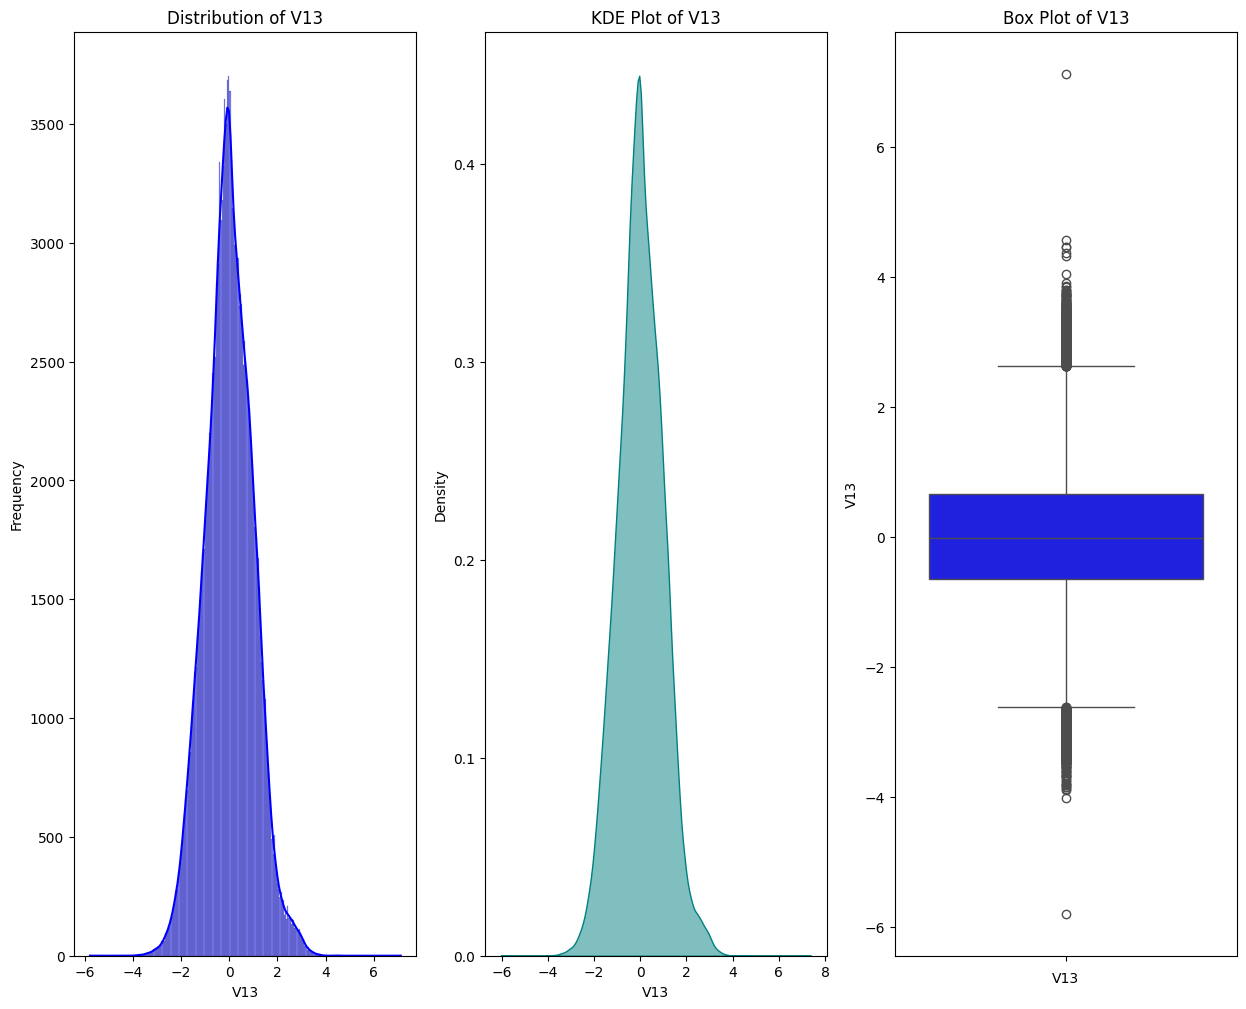

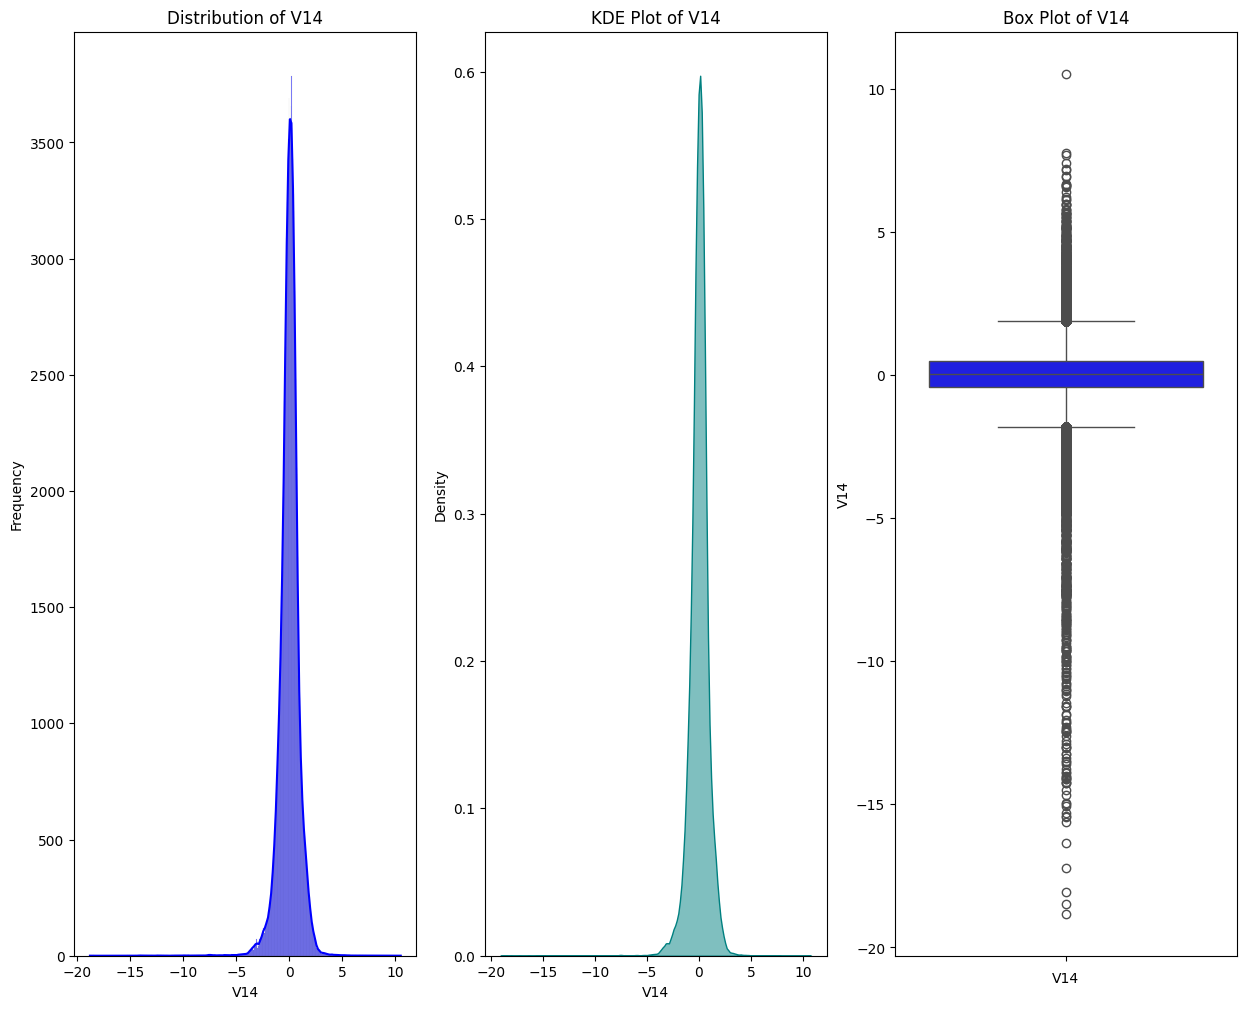

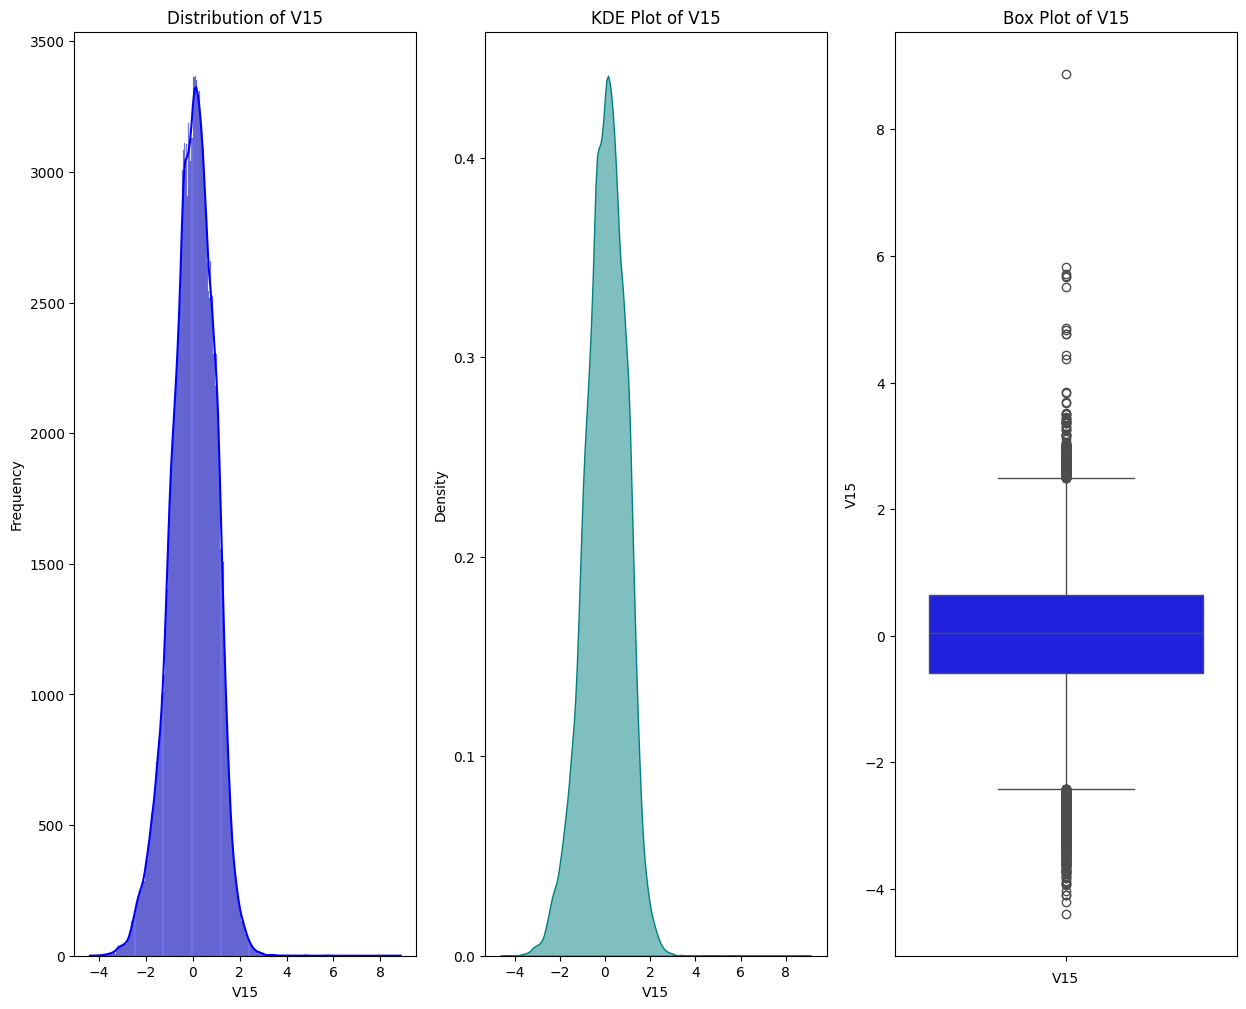

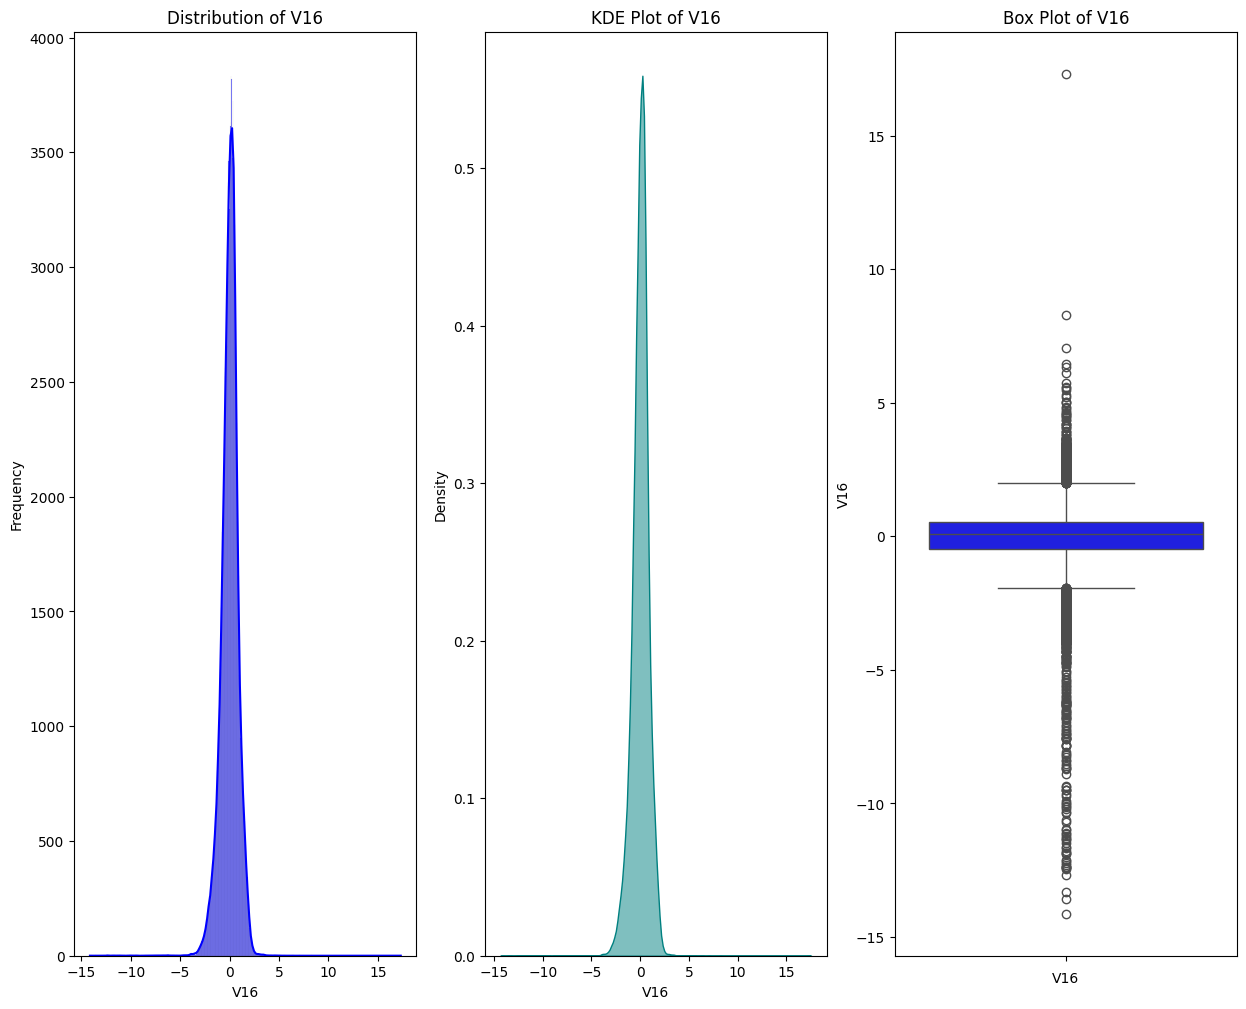

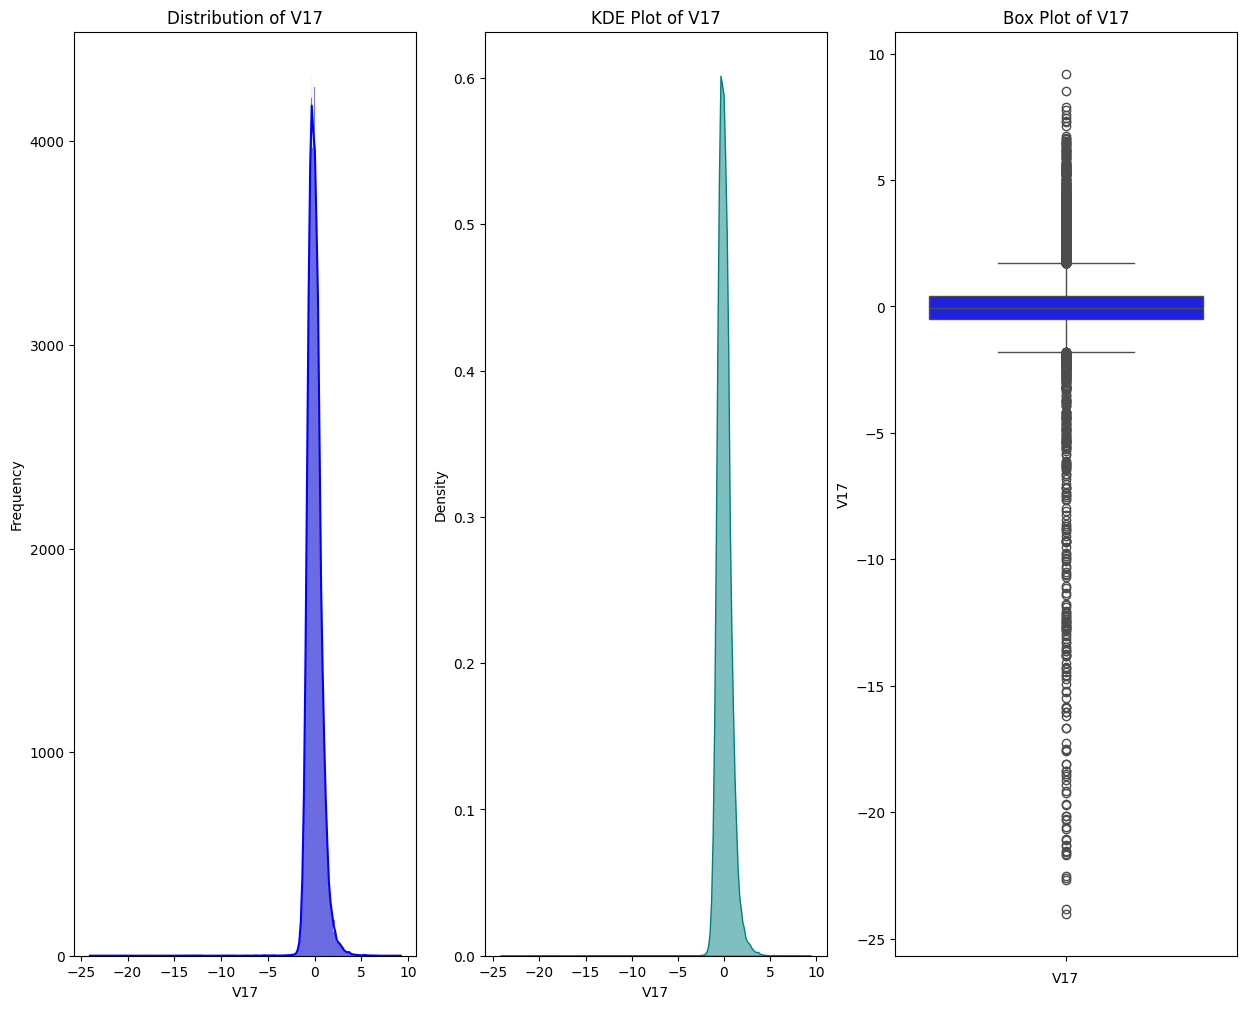

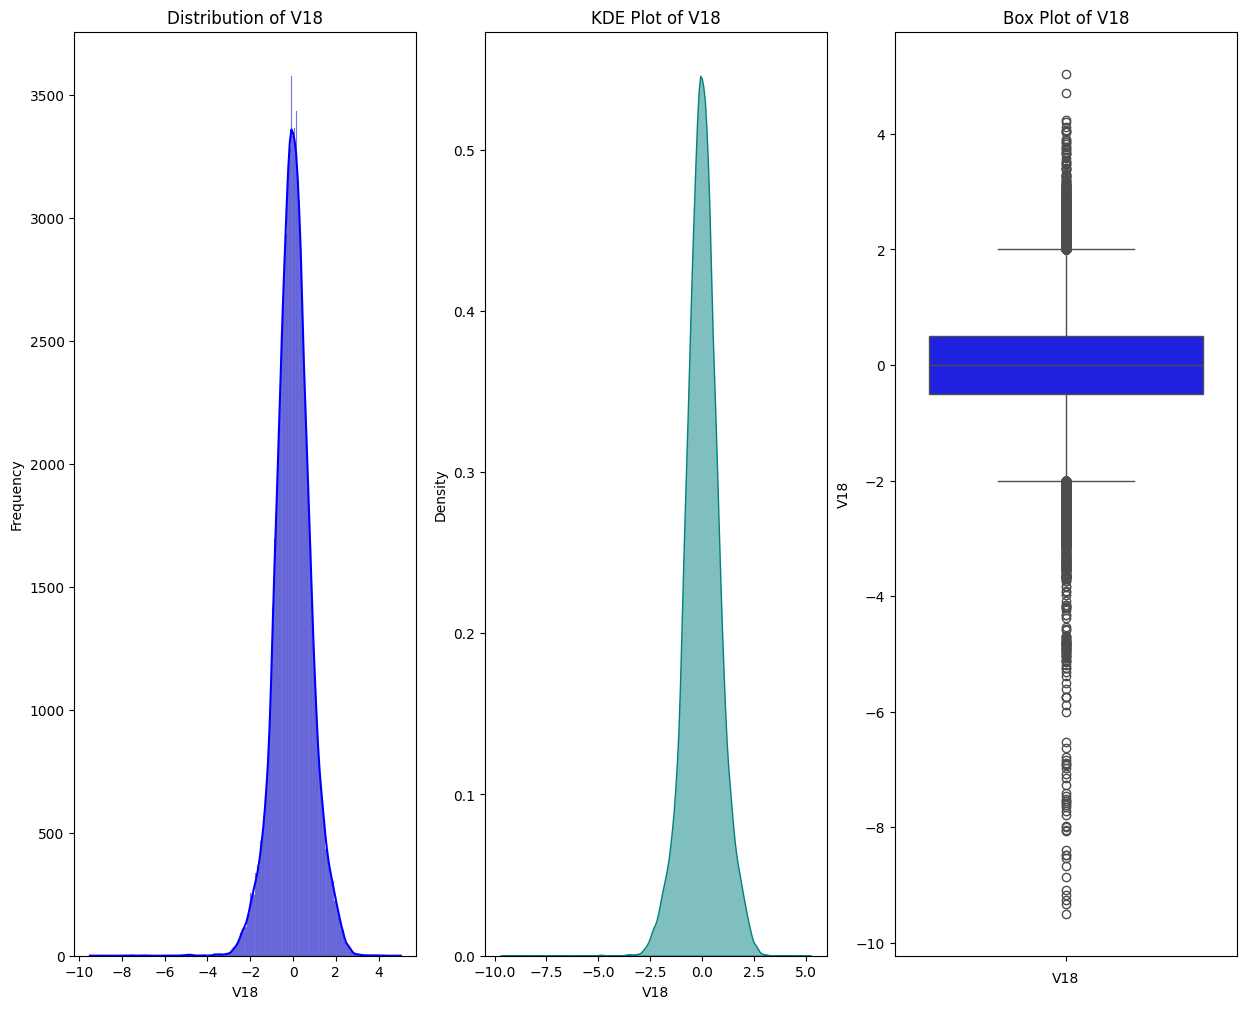

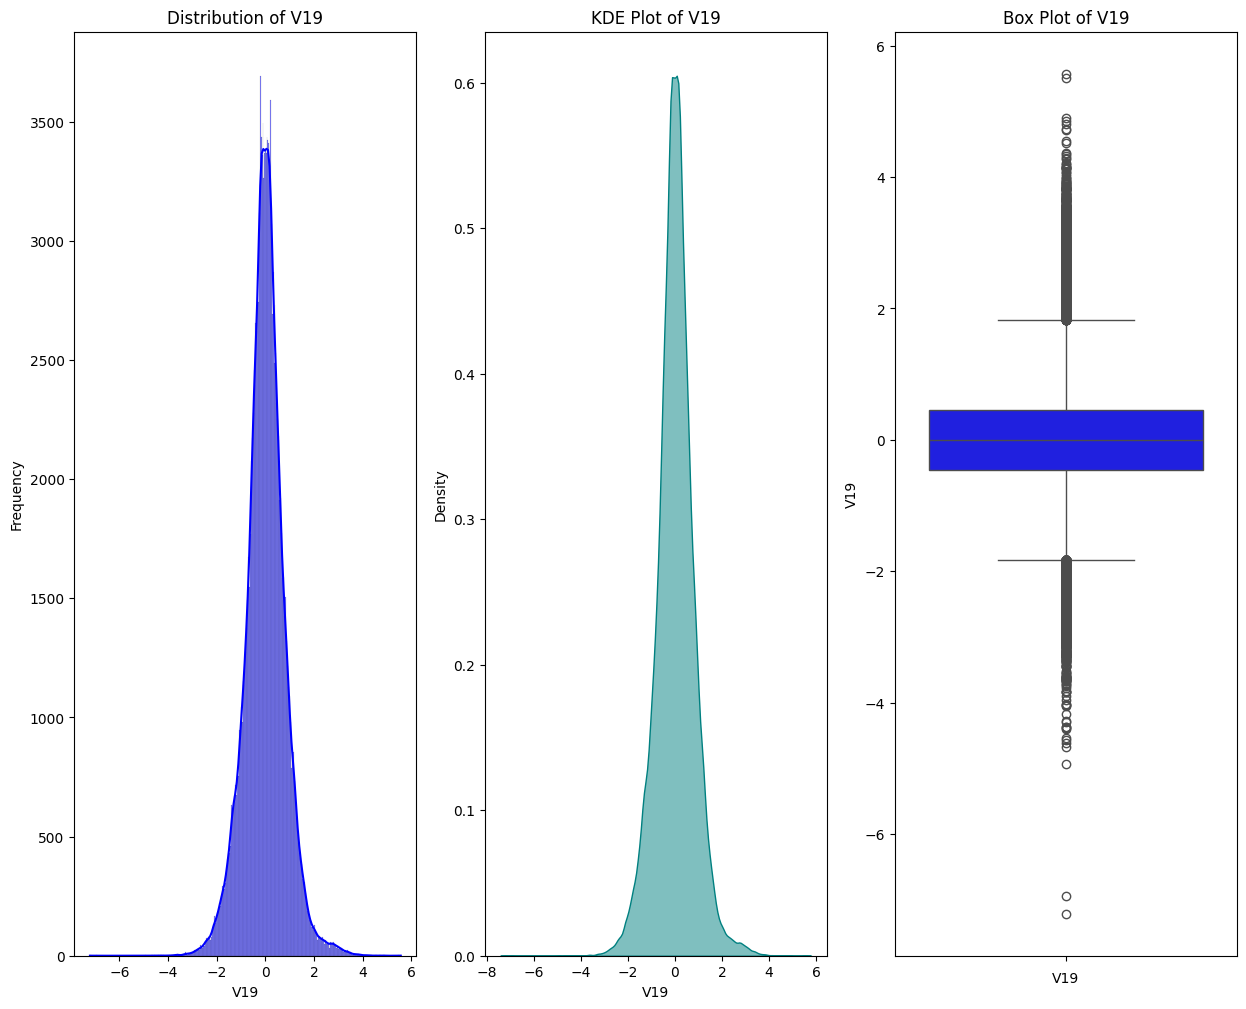

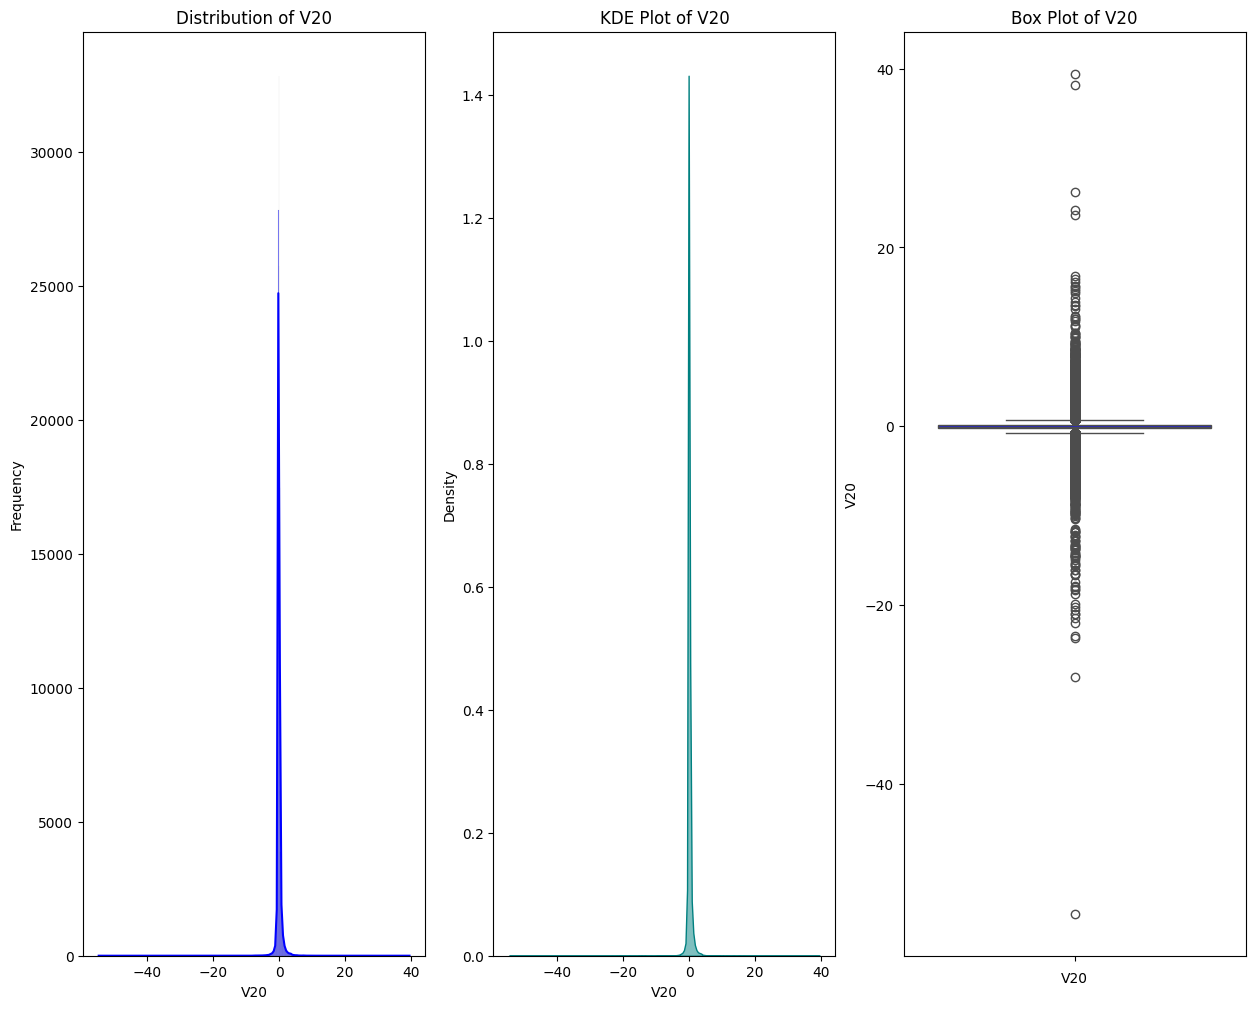

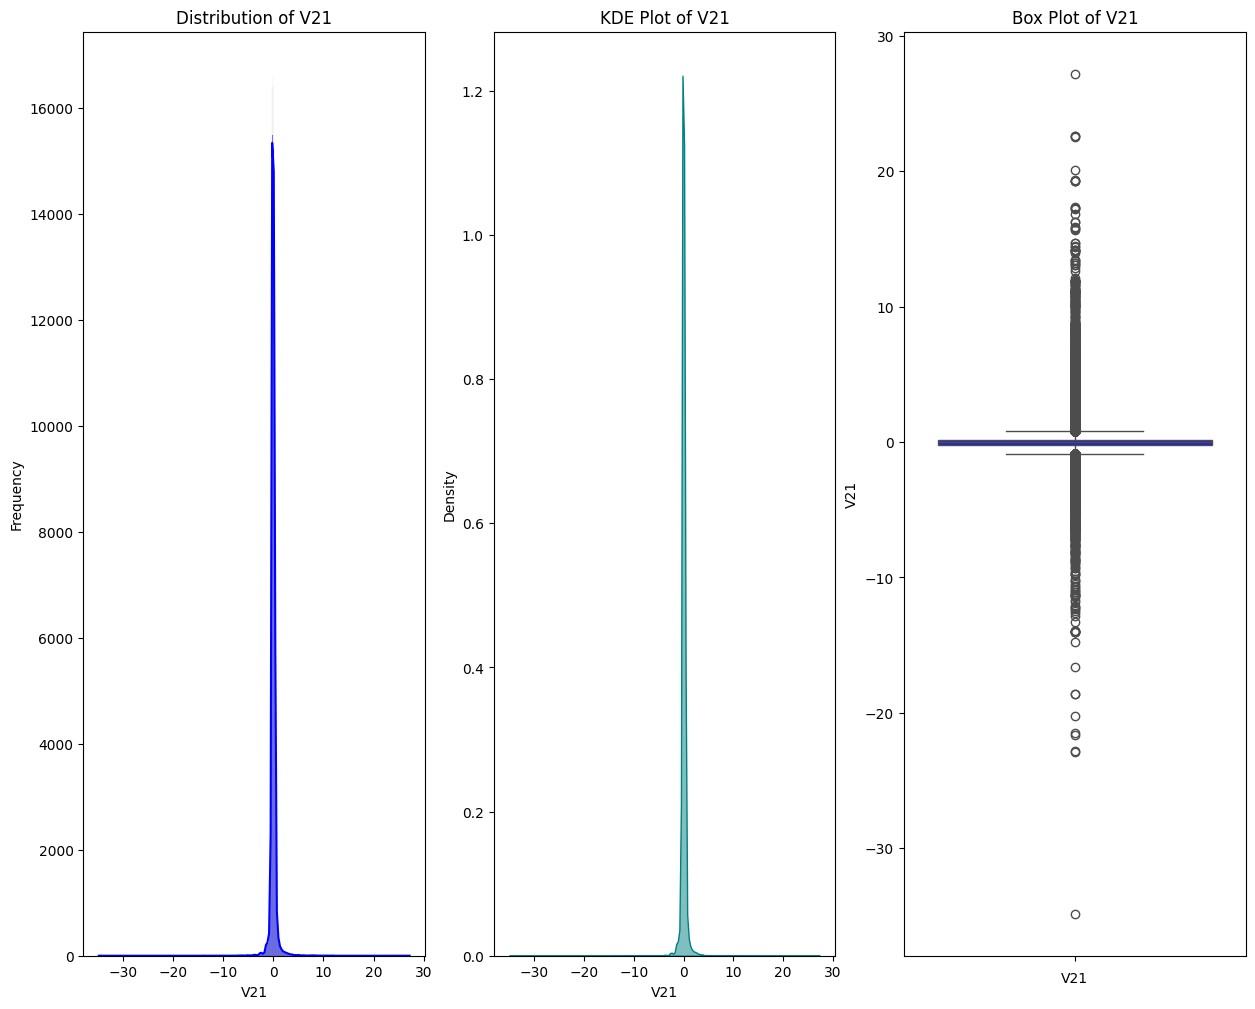

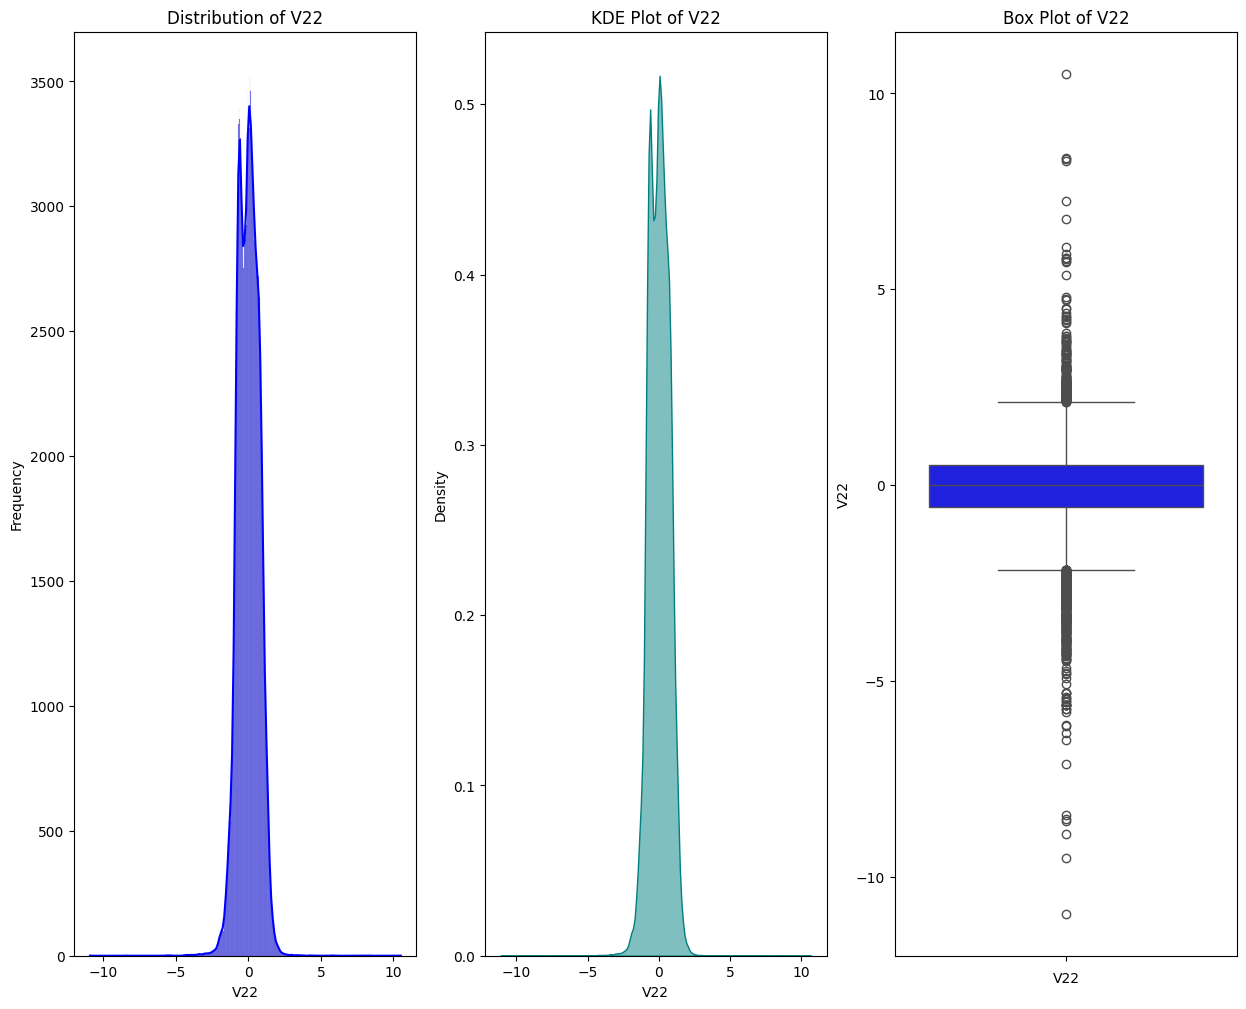

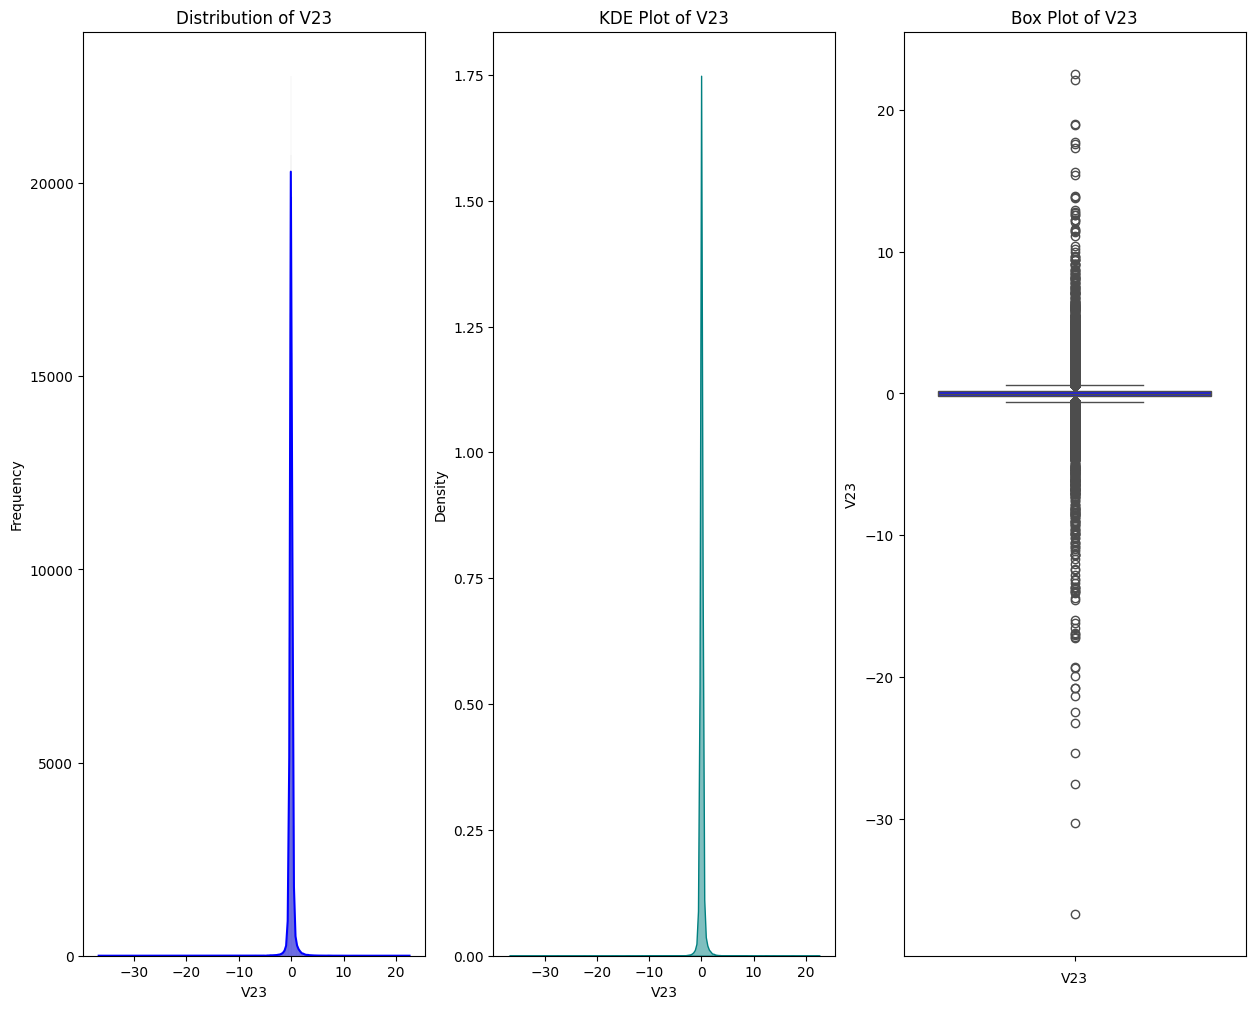

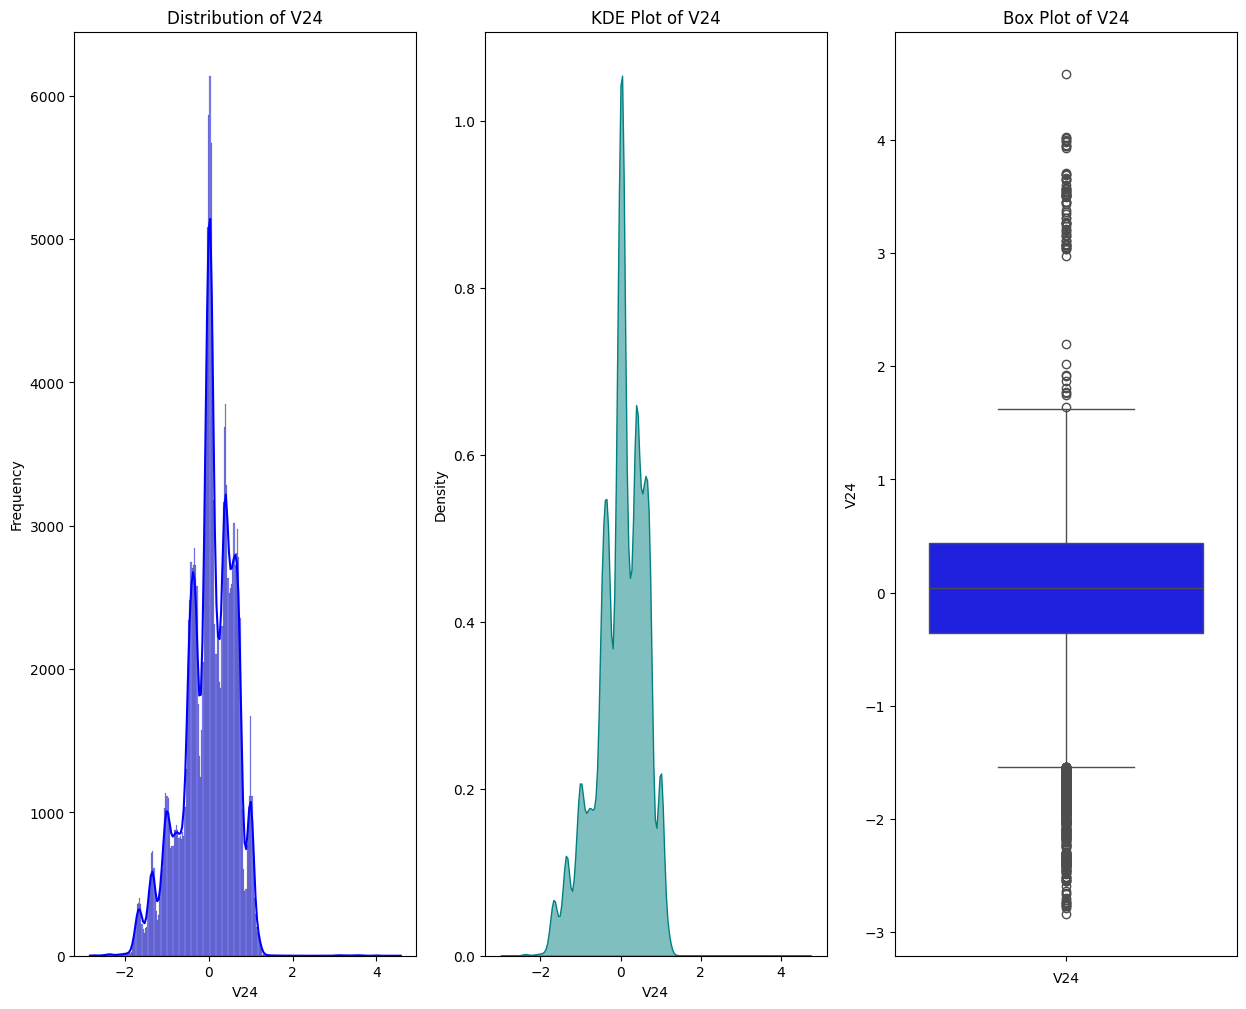

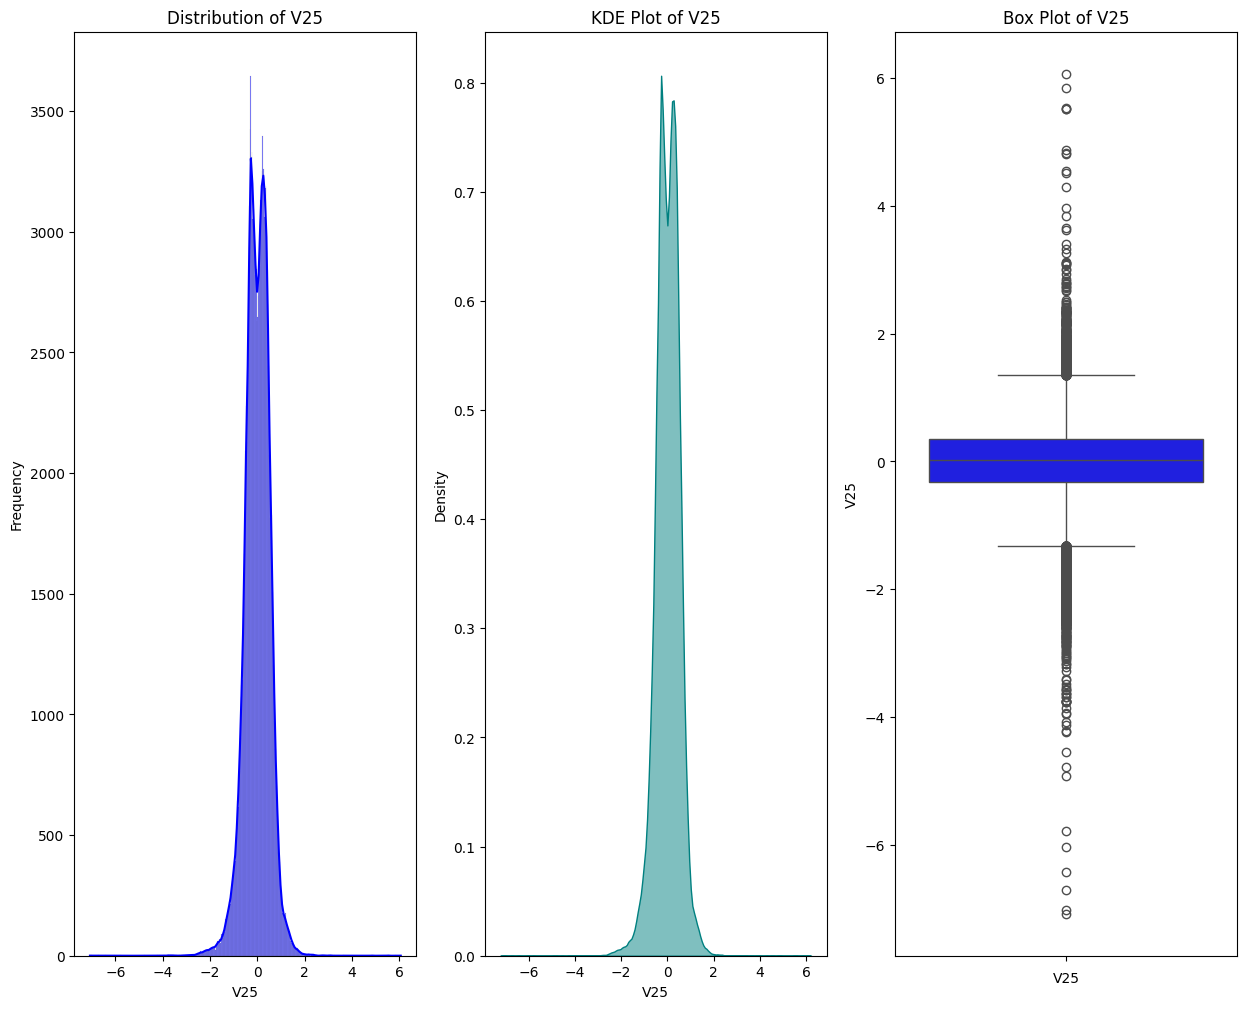

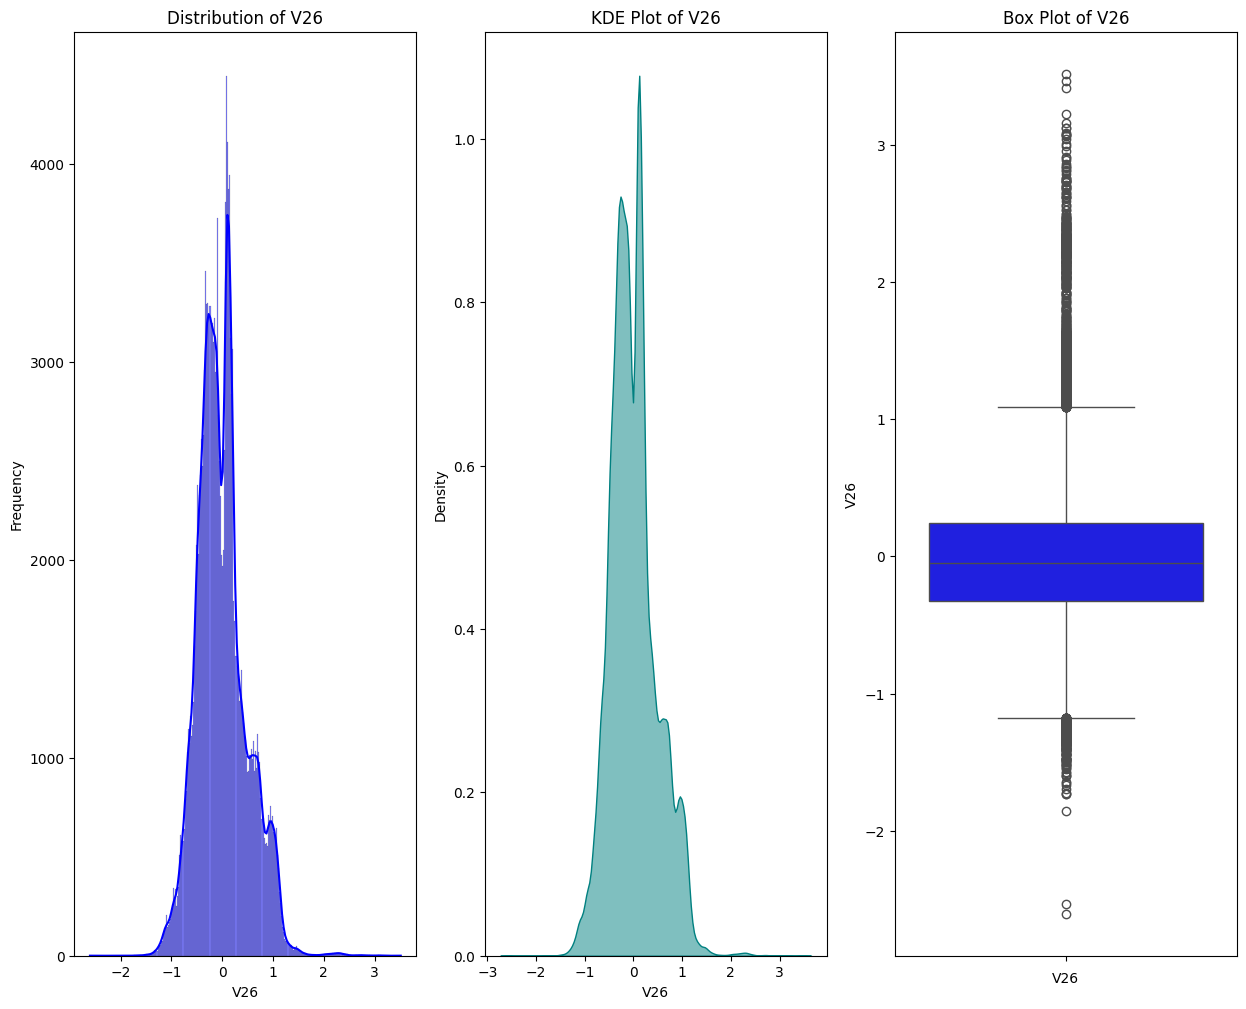

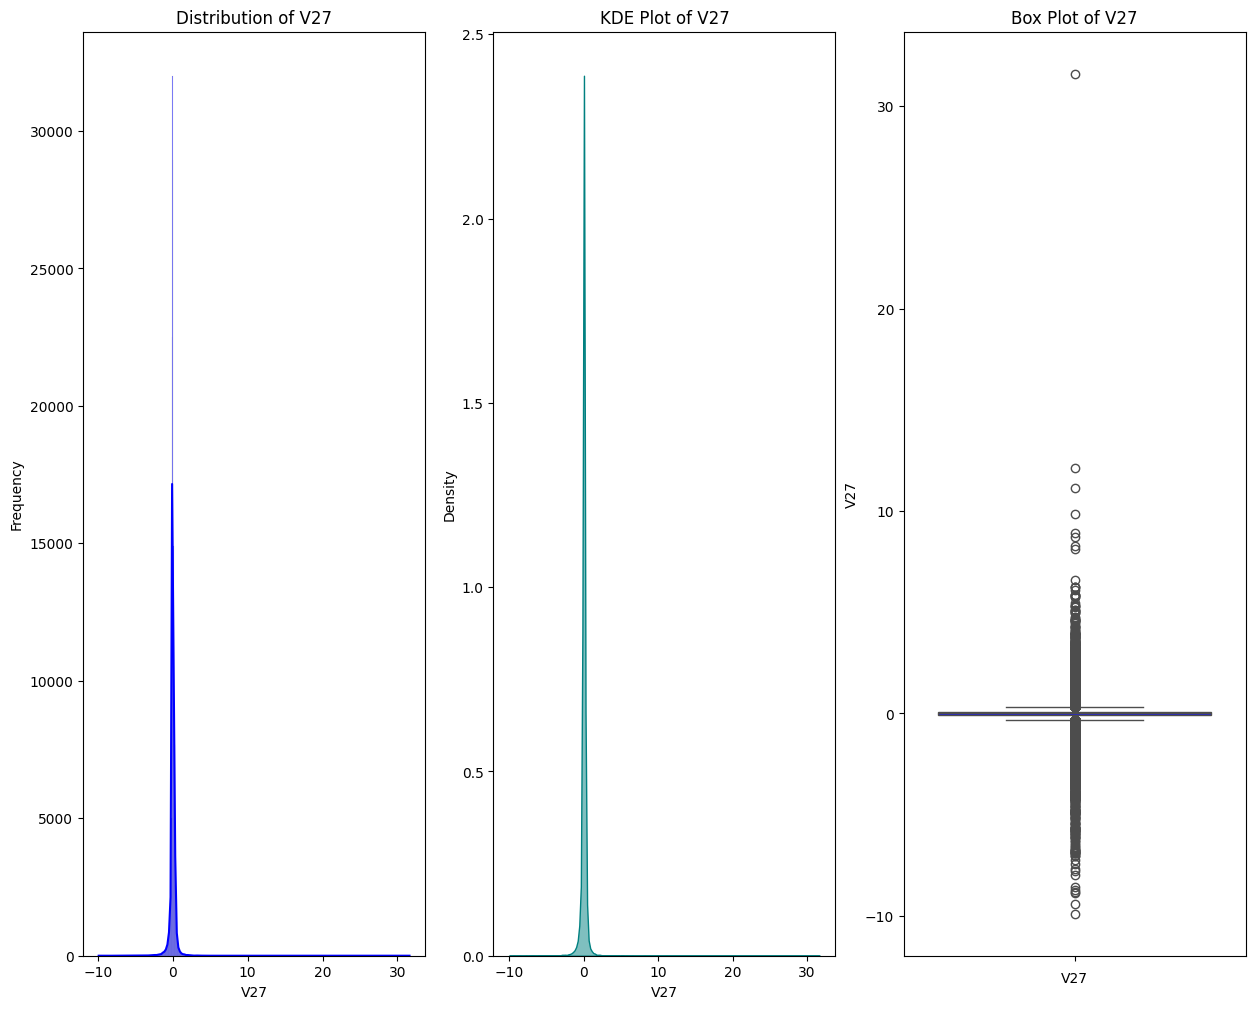

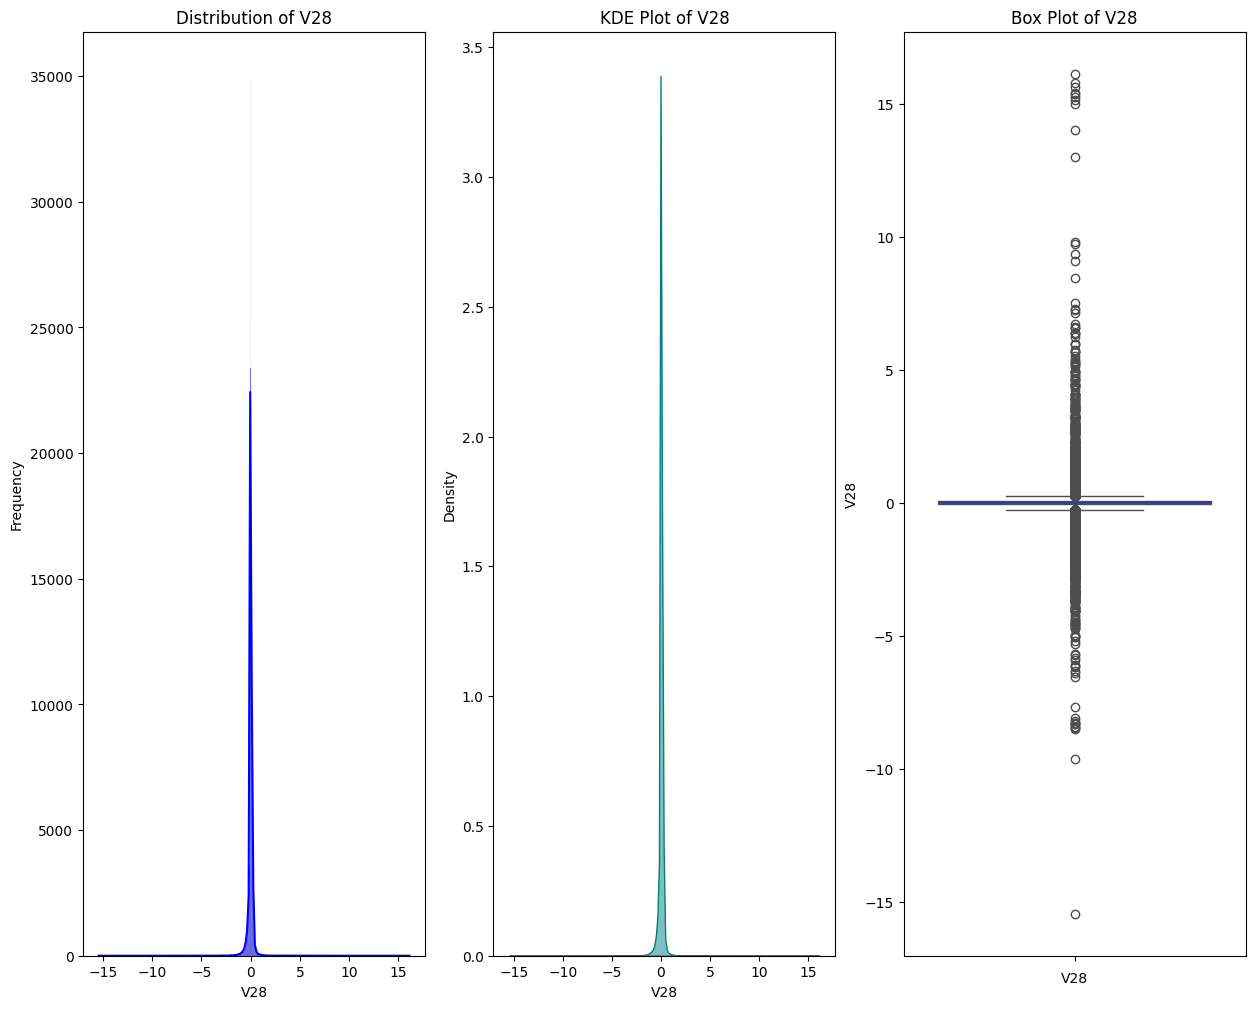

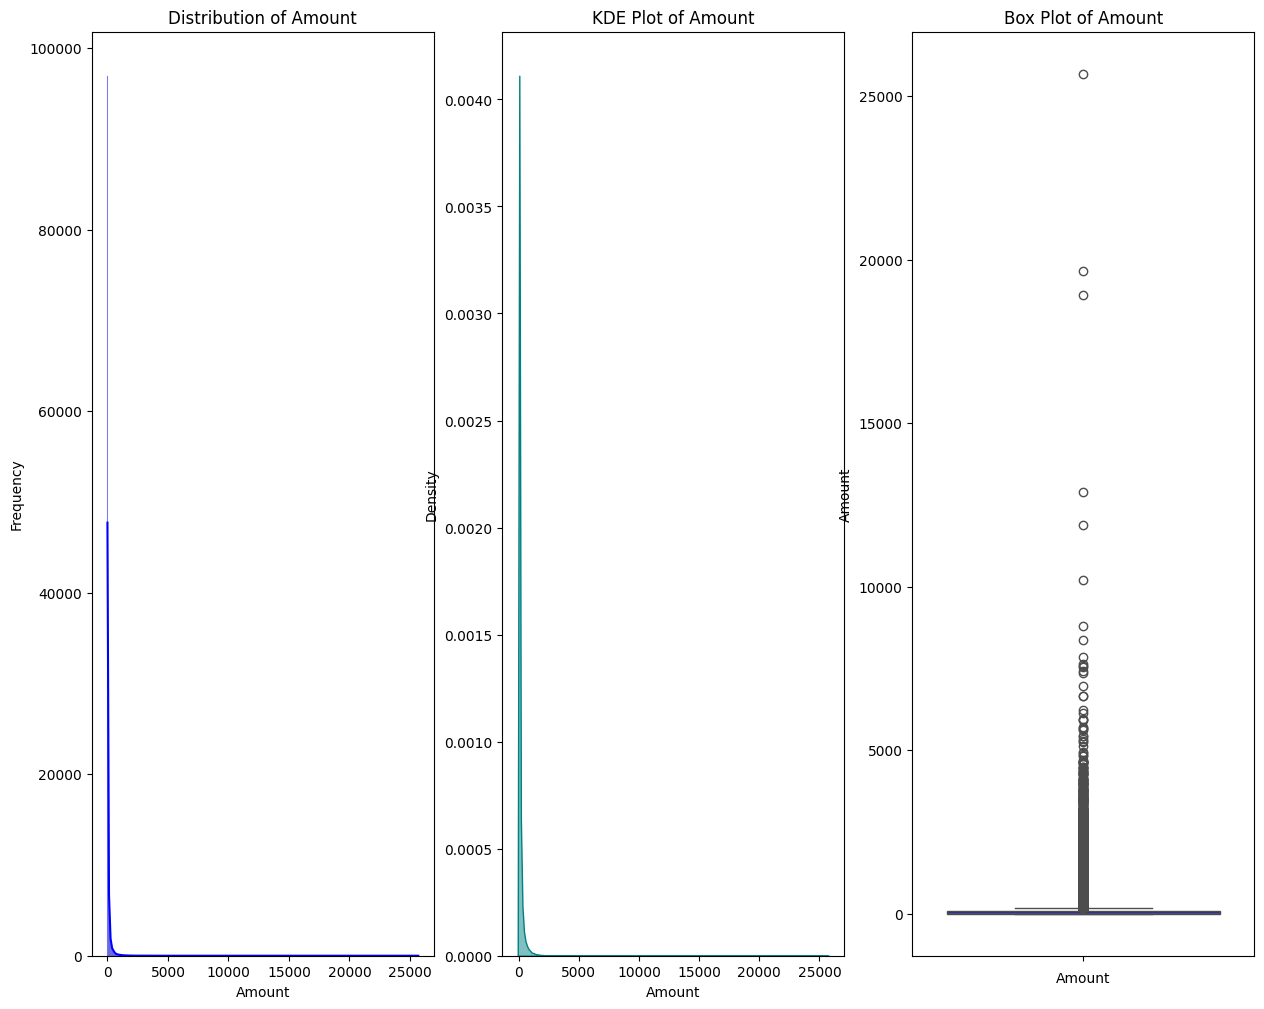

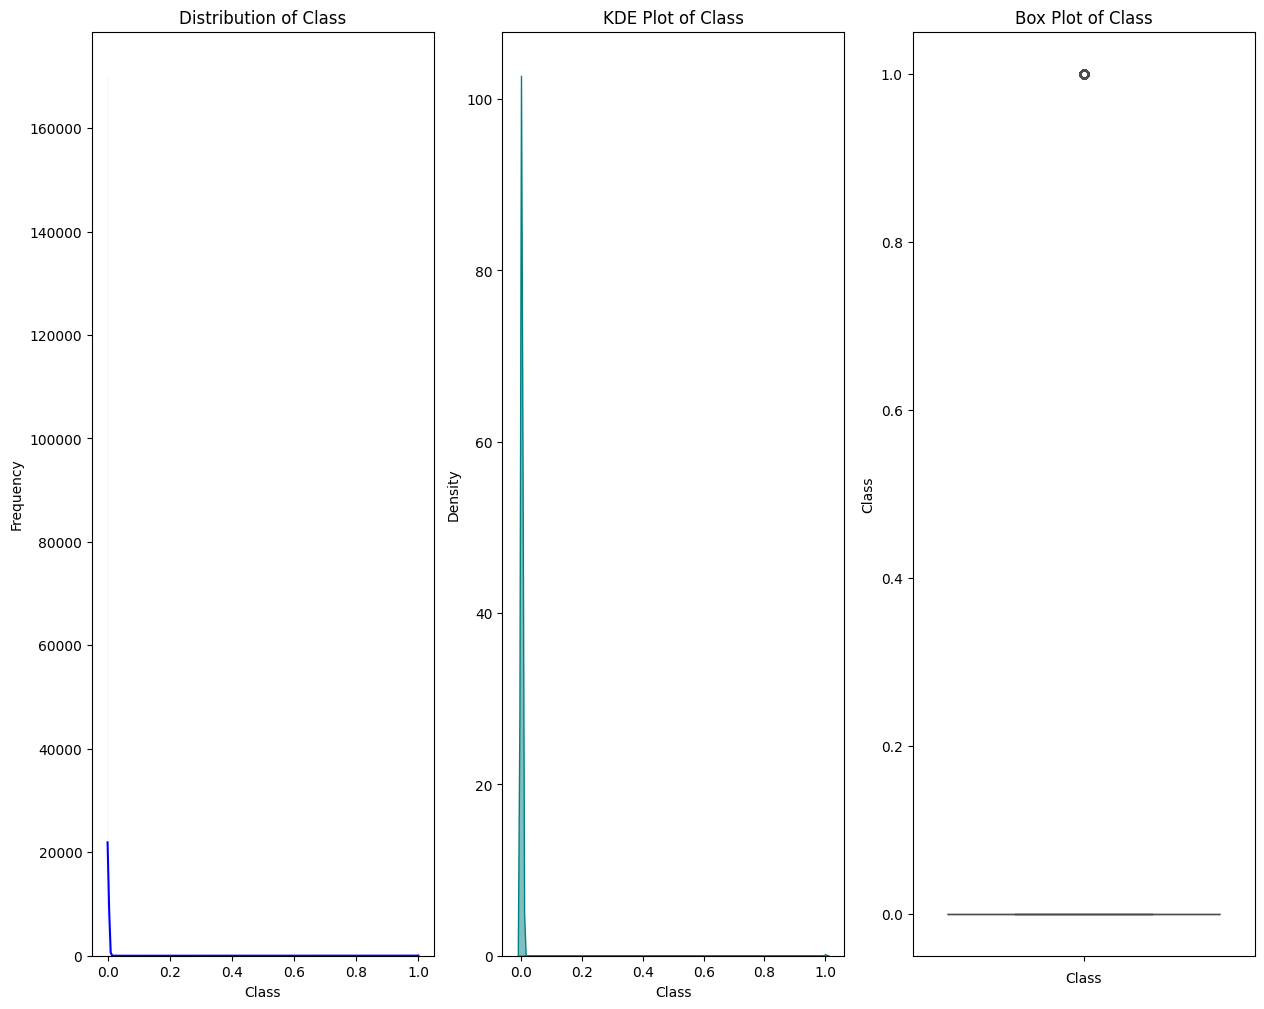

In [30]:
for feature in df.columns: 
    plot_numerical(df, feature)

## feature Relationship

### Numerical vs Numerical 

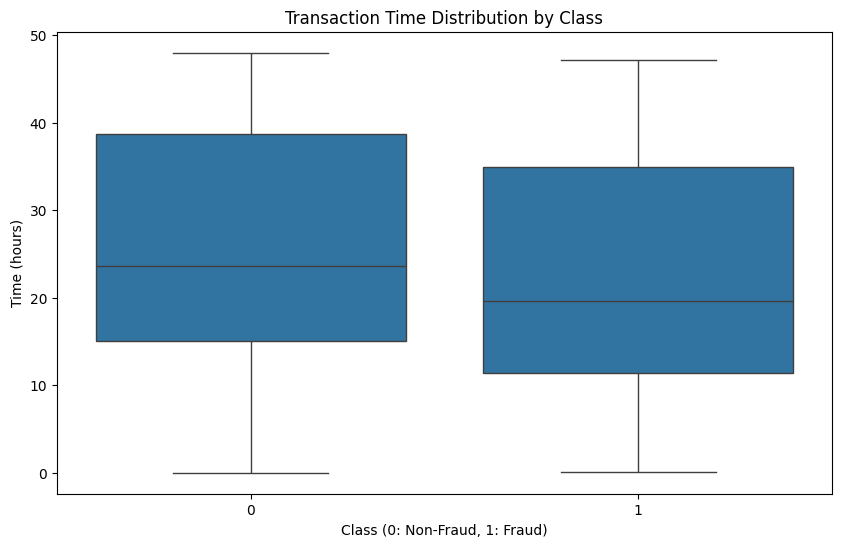

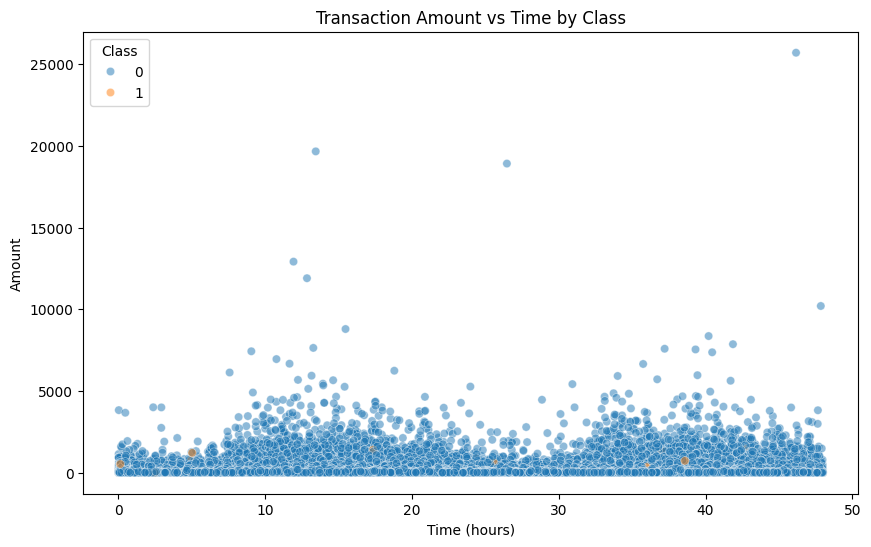

In [36]:
# Time vs Class: Boxplot to see distribution of transaction times for each class
plt.figure(figsize=(10,6))
sns.boxplot(x='Class', y='Time', data=df)
plt.title('Transaction Time Distribution by Class')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Time (hours)')
plt.show()

# Time vs Amount: Scatterplot to see relationship between time and transaction amount
plt.figure(figsize=(10,6))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.5)
plt.title('Transaction Amount vs Time by Class')
plt.xlabel('Time (hours)')
plt.ylabel('Amount')
plt.legend(title='Class')
plt.show()